# 05 Future 5-Min Return Baseline

## 1. Research Objective

This notebook studies whether Level2 microstructure features can predict the next 5-minute midpoint return.

Primary label:

```text
future_return_5m = mid_price(t + 5min) / mid_price(t) - 1
```

Direction label:

```text
future_direction_5m = -1 / 0 / 1
```

The key rule is that all features at minute `t` must only use information available at or before `t`. The future price at `t+5min` is used only for label construction.

A central design choice in this notebook is to treat **price group** as a parallel research dimension, not as a late-stage robustness afterthought. Since low-priced stocks have a larger tick size in percentage terms, their 5-minute return labels may be more discrete and contain more zero returns. Therefore, feature evaluation is always reported in two ways:

1. **Pooled sample IC**
2. **Price-group conditional IC** for Low-, Mid-, and High-Price groups


## 1.1 Notebook Structure

```text
Research sample
    ↓
Minute-level market state
    ↓
5-minute return label
    ↓
Price-group construction
    ↓
Master feature table
    ↓
Feature family construction
    ↓
Pooled IC + price-group IC + daily IC
    ↓
Feature screening
    ↓
Baseline model
```

The notebook is structured so that each feature family is evaluated using the same framework:

- Overall Pearson IC and Rank IC
- Daily Rank IC stability
- Price-group conditional IC
- Price-group daily IC stability


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

EPS = 1e-9


def safe_divide(a, b):
    return np.where(
        np.abs(b) > EPS,
        a / b,
        np.nan
    )


In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.ddb_client import connect_ddb

session = connect_ddb()


In [3]:
DB_PATH = "dfs://quota"

START_DATE = "2026.03.11"
END_DATE = "2026.04.10"

START_TIME = "09:30:00"
END_TIME = "10:00:00"

RANDOM_STATE = 42
N_STOCKS = 25

print("Database:", DB_PATH)
print("Sample period:", START_DATE, "to", END_DATE)
print("Intraday window:", START_TIME, "to", END_TIME)
print("N_STOCKS:", N_STOCKS)
print("RANDOM_STATE:", RANDOM_STATE)


Database: dfs://quota
Sample period: 2026.03.11 to 2026.04.10
Intraday window: 09:30:00 to 10:00:00
N_STOCKS: 25
RANDOM_STATE: 42


## 2. Research Sample

The first baseline uses a reproducible 25-stock sample. The universe is restricted to A-share equities using simple code-prefix rules to avoid mixing ETFs or other exchange-listed products into the stock prediction sample.

This keeps the notebook computationally manageable while preserving reproducibility.


In [4]:
# ============================================================
# Reproducible Random Stock Sampling
# ============================================================

universe_script = f"""
qtick = loadTable("{DB_PATH}", "qtick")

select distinct code
from qtick
where date >= {START_DATE}
  and date <= {END_DATE}
"""

stock_universe = session.run(universe_script)

print("Total securities in universe:", len(stock_universe))
display(stock_universe.head())

# ------------------------------------------------------------
# Identify A-share equity board by code prefix
# ------------------------------------------------------------

stock_universe["board"] = np.select(
    [
        stock_universe["code"].str.startswith(("300", "301")),
        stock_universe["code"].str.startswith(("000", "001", "002")),
        stock_universe["code"].str.startswith(("600", "601", "603", "605"))
    ],
    [
        "ChiNext",
        "SZ Main",
        "SH Main"
    ],
    default="Other"
)

display(
    stock_universe["board"]
    .value_counts()
    .rename("n_securities")
    .to_frame()
)

eligible_pool = stock_universe[
    stock_universe["board"].isin(
        ["SZ Main", "ChiNext", "SH Main"]
    )
].copy()

stock_pool = eligible_pool.sample(
    n=min(N_STOCKS, len(eligible_pool)),
    random_state=RANDOM_STATE
).copy()

sample_codes = (
    stock_pool["code"]
    .drop_duplicates()
    .tolist()
)

codes_ddb = (
    "["
    + ",".join([f'"{code}"' for code in sample_codes])
    + "]"
)

print("Eligible stocks:", len(eligible_pool))
print("Selected stocks:", len(sample_codes))
display(stock_pool.head(10))


Total securities in universe: 84045


,code
0,000001.SH
1,000015.SH
2,000017.SZ
3,000018.SH
4,000020.SZ


,n_securities
board,
Other,79296
SH Main,1704
SZ Main,1650
ChiNext,1395


Eligible stocks: 4749
Selected stocks: 25


,code,board
61866,000766.SZ,SZ Main
19468,300045.SZ,ChiNext
4631,600282.SH,SH Main
34898,300327.SZ,ChiNext
27742,600168.SH,SH Main
74030,600601.SH,SH Main
58693,600880.SH,SH Main
54305,002867.SZ,SZ Main
20268,603679.SH,SH Main
34941,300822.SZ,ChiNext


## 3. Load `qtick` Snapshot Data

The first version builds a 1-minute panel from `qtick` snapshot data. Only necessary fields are queried to reduce DolphinDB transfer size.


In [5]:
qtick_cols = """
code, date, time,
new_price,
bp0, ap0,
bv0, av0,
bv1, av1,
bv2, av2,
bv3, av3,
bv4, av4,
sum_volume, sum_amount
"""

qtick_script = f"""
qtick = loadTable("{DB_PATH}", "qtick")

select {qtick_cols}
from qtick
where code in {codes_ddb}
  and date >= {START_DATE}
  and date <= {END_DATE}
  and time >= {START_TIME}.000
  and time <= {END_TIME}.000
order by code, date, time
"""

qtick = session.run(qtick_script)

print("qtick shape:", qtick.shape)
display(qtick.head())


qtick shape: (306169, 18)


,code,date,time,new_price,bp0,ap0,bv0,av0,bv1,av1,bv2,av2,bv3,av3,bv4,av4,sum_volume,sum_amount
0,000170.SH,2026-03-11,1970-01-01 09:30:04,6172.8769,0.0,0.0,0,0,0,0,0,0,0,0,0,0,230930,5.936157e+08
1,000170.SH,2026-03-11,1970-01-01 09:30:07,6177.6326,0.0,0.0,0,0,0,0,0,0,0,0,0,0,260303,6.499307e+08
2,000170.SH,2026-03-11,1970-01-01 09:30:13,6180.2230,0.0,0.0,0,0,0,0,0,0,0,0,0,0,369168,8.023257e+08
3,000170.SH,2026-03-11,1970-01-01 09:30:19,6180.0460,0.0,0.0,0,0,0,0,0,0,0,0,0,0,408255,8.872205e+08
4,000170.SH,2026-03-11,1970-01-01 09:30:22,6176.1868,0.0,0.0,0,0,0,0,0,0,0,0,0,0,471049,1.038405e+09


## 4. Minute-Level Market State

Each final row represents one stock-minute:

```text
stock × date × minute
```

The row stores the last observable snapshot within that minute.


In [6]:
qtick = qtick.copy()

date_str = pd.to_datetime(qtick["date"]).dt.strftime("%Y-%m-%d")

time_str = qtick["time"].astype(str)
time_str = (
    time_str
    .str.replace("1970-01-01 ", "", regex=False)
    .str.replace("1900-01-01 ", "", regex=False)
)

qtick["datetime"] = pd.to_datetime(
    date_str + " " + time_str,
    format="mixed"
)

qtick["time_clean"] = qtick["datetime"].dt.strftime("%H:%M:%S.%f")
qtick["time_clean"] = qtick["time_clean"].str.replace(".000000", "", regex=False)

qtick["minute"] = qtick["datetime"].dt.floor("min")

display(qtick[["code", "date", "time_clean", "datetime", "minute"]].head())


,code,date,time_clean,datetime,minute
0,000170.SH,2026-03-11,09:30:04,2026-03-11 09:30:04,2026-03-11 09:30:00
1,000170.SH,2026-03-11,09:30:07,2026-03-11 09:30:07,2026-03-11 09:30:00
2,000170.SH,2026-03-11,09:30:13,2026-03-11 09:30:13,2026-03-11 09:30:00
3,000170.SH,2026-03-11,09:30:19,2026-03-11 09:30:19,2026-03-11 09:30:00
4,000170.SH,2026-03-11,09:30:22,2026-03-11 09:30:22,2026-03-11 09:30:00


In [7]:
qtick["bp0"] = pd.to_numeric(qtick["bp0"], errors="coerce").replace(0, np.nan)
qtick["ap0"] = pd.to_numeric(qtick["ap0"], errors="coerce").replace(0, np.nan)

qtick["mid_price"] = (qtick["bp0"] + qtick["ap0"]) / 2

display(qtick[["code", "date", "datetime", "bp0", "ap0", "mid_price"]].head())


,code,date,datetime,bp0,ap0,mid_price
0,000170.SH,2026-03-11,2026-03-11 09:30:04,NaN,NaN,NaN
1,000170.SH,2026-03-11,2026-03-11 09:30:07,NaN,NaN,NaN
2,000170.SH,2026-03-11,2026-03-11 09:30:13,NaN,NaN,NaN
3,000170.SH,2026-03-11,2026-03-11 09:30:19,NaN,NaN,NaN
4,000170.SH,2026-03-11,2026-03-11 09:30:22,NaN,NaN,NaN


In [8]:
minute_panel = (
    qtick
    .sort_values(["code", "date", "datetime"])
    .groupby(["code", "date", "minute"])
    .agg(
        mid_price=("mid_price", "last"),
        last_price=("new_price", "last"),
        bp0=("bp0", "last"),
        ap0=("ap0", "last"),
        bv0=("bv0", "last"),
        av0=("av0", "last"),
        bv1=("bv1", "last"),
        av1=("av1", "last"),
        bv2=("bv2", "last"),
        av2=("av2", "last"),
        bv3=("bv3", "last"),
        av3=("av3", "last"),
        bv4=("bv4", "last"),
        av4=("av4", "last"),
        sum_volume=("sum_volume", "last"),
        sum_amount=("sum_amount", "last")
    )
    .reset_index()
)

minute_panel = minute_panel.sort_values(["code", "date", "minute"])

print("minute_panel shape:", minute_panel.shape)
display(minute_panel.head())


minute_panel shape: (16847, 19)


,code,date,minute,mid_price,last_price,bp0,ap0,bv0,av0,bv1,av1,bv2,av2,bv3,av3,bv4,av4,sum_volume,sum_amount
0,000170.SH,2026-03-11,2026-03-11 09:30:00,NaN,6169.1126,NaN,NaN,0,0,0,0,0,0,0,0,0,0,758547,1.908851e+09
1,000170.SH,2026-03-11,2026-03-11 09:31:00,NaN,6180.3875,NaN,NaN,0,0,0,0,0,0,0,0,0,0,1235805,3.336084e+09
2,000170.SH,2026-03-11,2026-03-11 09:32:00,NaN,6172.2541,NaN,NaN,0,0,0,0,0,0,0,0,0,0,1581843,4.418654e+09
3,000170.SH,2026-03-11,2026-03-11 09:33:00,NaN,6167.3278,NaN,NaN,0,0,0,0,0,0,0,0,0,0,1914088,5.582274e+09
4,000170.SH,2026-03-11,2026-03-11 09:34:00,NaN,6169.4988,NaN,NaN,0,0,0,0,0,0,0,0,0,0,2257022,6.814830e+09


## 5. Label Construction

The primary prediction target is the future 5-minute midpoint return:

```text
future_return_5m = mid_price(t + 5min) / mid_price(t) - 1
```

The direction label is defined as a three-state variable:

```text
-1 = Negative return
 0 = Zero return
 1 = Positive return
```

Zero return is kept as a separate state because short-horizon midpoint returns may be discrete, especially for low-priced stocks.


In [9]:
minute_panel["future_mid_5m"] = (
    minute_panel
    .groupby(["code", "date"])["mid_price"]
    .shift(-5)
)

minute_panel["future_return_5m"] = (
    minute_panel["future_mid_5m"] / minute_panel["mid_price"] - 1
)

minute_panel["future_direction_5m"] = np.select(
    [
        minute_panel["future_return_5m"] > 0,
        minute_panel["future_return_5m"] < 0
    ],
    [1, -1],
    default=0
)

label_df = minute_panel.dropna(
    subset=["mid_price", "future_mid_5m", "future_return_5m"]
).copy()

print("label_df shape:", label_df.shape)
display(label_df[[
    "code", "date", "minute", "mid_price", "future_mid_5m",
    "future_return_5m", "future_direction_5m"
]].head(10))


label_df shape: (13518, 22)


,code,date,minute,mid_price,future_mid_5m,future_return_5m,future_direction_5m
660,000570.SZ,2026-03-11,2026-03-11 09:30:00,6.305,6.315,0.001586,1
661,000570.SZ,2026-03-11,2026-03-11 09:31:00,6.305,6.290,-0.002379,-1
662,000570.SZ,2026-03-11,2026-03-11 09:32:00,6.295,6.305,0.001589,1
663,000570.SZ,2026-03-11,2026-03-11 09:33:00,6.265,6.295,0.004789,1
664,000570.SZ,2026-03-11,2026-03-11 09:34:00,6.295,6.285,-0.001589,-1
665,000570.SZ,2026-03-11,2026-03-11 09:35:00,6.315,6.275,-0.006334,-1
666,000570.SZ,2026-03-11,2026-03-11 09:36:00,6.290,6.265,-0.003975,-1
667,000570.SZ,2026-03-11,2026-03-11 09:37:00,6.305,6.255,-0.007930,-1
668,000570.SZ,2026-03-11,2026-03-11 09:38:00,6.295,6.265,-0.004766,-1
669,000570.SZ,2026-03-11,2026-03-11 09:39:00,6.285,6.255,-0.004773,-1


In [10]:
# ============================================================
# Exact 5-Minute Horizon Check
# ============================================================

minute_panel["future_minute_5m"] = (
    minute_panel
    .groupby(["code", "date"])["minute"]
    .shift(-5)
)

minute_panel["actual_horizon_min"] = (
    (minute_panel["future_minute_5m"] - minute_panel["minute"])
    .dt.total_seconds() / 60
)

display(
    minute_panel["actual_horizon_min"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("count")
    .to_frame()
)


,count
actual_horizon_min,
5.0,14097
NaN,2750


## 6. Label Diagnostics and Price-Group Construction

This section validates the label before feature engineering.

Price group is constructed immediately after label diagnostics and then merged into the master feature table. This makes price group a parallel dimension throughout the rest of the notebook.


In [11]:
display(label_df["future_return_5m"].describe())

print("Direction balance:")
direction_summary = (
    label_df["future_direction_5m"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)
direction_summary["ratio"] = direction_summary["count"] / direction_summary["count"].sum()
direction_summary.index = direction_summary.index.map({-1: "Negative", 0: "Zero", 1: "Positive"})
display(direction_summary)


count    13518.000000
mean        -0.000133
std          0.005567
min         -0.076274
25%         -0.002864
50%          0.000000
75%          0.002283
max          0.130449
Name: future_return_5m, dtype: float64

Direction balance:


,count,ratio
future_direction_5m,,
Negative,6466,0.478325
Zero,1352,0.100015
Positive,5700,0.421660


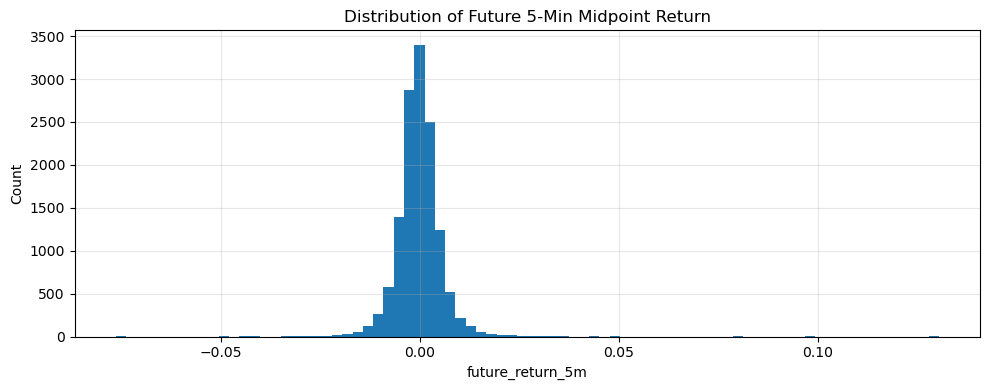

In [12]:
plt.figure(figsize=(10, 4))
plt.hist(label_df["future_return_5m"], bins=80)
plt.title("Distribution of Future 5-Min Midpoint Return")
plt.xlabel("future_return_5m")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
zero_return_by_stock = (
    label_df
    .assign(is_zero_return=lambda x: x["future_return_5m"].eq(0))
    .groupby("code")
    .agg(
        n_obs=("future_return_5m", "size"),
        zero_return_ratio=("is_zero_return", "mean"),
        avg_mid_price=("mid_price", "mean")
    )
    .sort_values("zero_return_ratio", ascending=False)
)

display(zero_return_by_stock)


,n_obs,zero_return_ratio,avg_mid_price
code,,,
300247.SZ,572,0.250000,4.634283
600880.SH,554,0.247292,4.946164
300315.SZ,572,0.236014,5.005341
600168.SH,557,0.231598,5.233070
300338.SZ,562,0.213523,3.787660
000570.SZ,571,0.157618,5.740517
600789.SH,559,0.152057,8.481503
600282.SH,558,0.127240,5.520869
002867.SZ,568,0.123239,11.948715


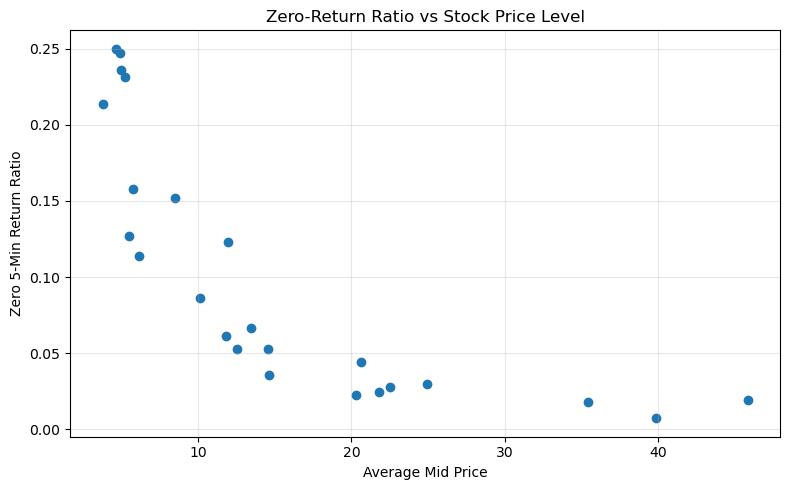

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(zero_return_by_stock["avg_mid_price"], zero_return_by_stock["zero_return_ratio"])
plt.xlabel("Average Mid Price")
plt.ylabel("Zero 5-Min Return Ratio")
plt.title("Zero-Return Ratio vs Stock Price Level")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [15]:
label_comparison = minute_panel.copy()

label_comparison["future_last_price_5m"] = (
    label_comparison
    .groupby(["code", "date"])["last_price"]
    .shift(-5)
)

label_comparison["future_return_5m_last"] = (
    label_comparison["future_last_price_5m"] / label_comparison["last_price"] - 1
)

label_comparison = label_comparison.dropna(
    subset=["future_return_5m", "future_return_5m_last"]
).copy()

comparison_summary = pd.DataFrame({
    "Mid Price Return": [
        label_comparison["future_return_5m"].std(),
        label_comparison["future_return_5m"].eq(0).mean()
    ],
    "Last Price Return": [
        label_comparison["future_return_5m_last"].std(),
        label_comparison["future_return_5m_last"].eq(0).mean()
    ]
}, index=["Return Std", "Zero Return Ratio"])

display(comparison_summary)


,Mid Price Return,Last Price Return
Return Std,0.005567,0.005662
Zero Return Ratio,0.100015,0.105859


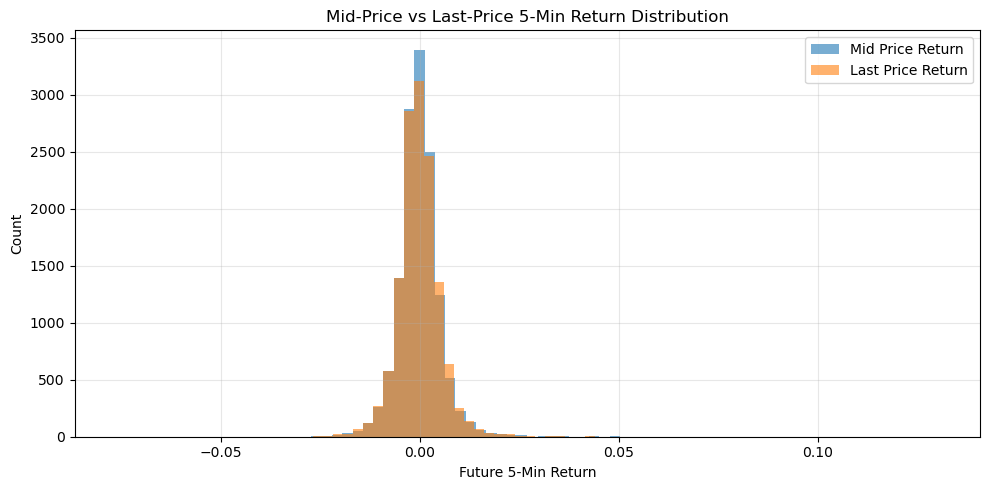

In [16]:
plt.figure(figsize=(10, 5))
plt.hist(label_comparison["future_return_5m"], bins=80, alpha=0.6, label="Mid Price Return")
plt.hist(label_comparison["future_return_5m_last"], bins=80, alpha=0.6, label="Last Price Return")
plt.xlabel("Future 5-Min Return")
plt.ylabel("Count")
plt.title("Mid-Price vs Last-Price 5-Min Return Distribution")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6.1 Price-Level Stratified Label Analysis

The price-level split is not a late-stage robustness check. It is part of the core research design because label discreteness differs substantially across price levels.

The notebook uses three price groups based on each stock's average midpoint price:

```text
Low Price / Mid Price / High Price
```

All subsequent feature-family evaluations are reported for both the pooled sample and these price groups.


In [17]:
stock_price_level = (
    label_df
    .groupby("code")
    .agg(
        avg_mid_price=("mid_price", "mean"),
        zero_return_ratio=("future_return_5m", lambda x: (x == 0).mean()),
        return_std=("future_return_5m", "std"),
        n_obs=("future_return_5m", "size")
    )
    .reset_index()
)

stock_price_level["price_group"] = pd.qcut(
    stock_price_level["avg_mid_price"],
    q=3,
    labels=["Low Price", "Mid Price", "High Price"]
)

display(stock_price_level.sort_values("avg_mid_price"))


,code,avg_mid_price,zero_return_ratio,return_std,n_obs,price_group
8,300338.SZ,3.787660,0.213523,0.005297,562,Low Price
5,300247.SZ,4.634283,0.250000,0.004004,572,Low Price
19,600880.SH,4.946164,0.247292,0.003591,554,Low Price
6,300315.SZ,5.005341,0.236014,0.003888,572,Low Price
14,600168.SH,5.233070,0.231598,0.004241,557,Low Price
15,600282.SH,5.520869,0.127240,0.005870,558,Low Price
0,000570.SZ,5.740517,0.157618,0.004301,571,Low Price
16,600403.SH,6.166264,0.113718,0.007914,554,Low Price
18,600789.SH,8.481503,0.152057,0.003107,559,Mid Price
17,600601.SH,10.152077,0.086331,0.005020,556,Mid Price


In [18]:
label_price_df = label_df.merge(
    stock_price_level[["code", "avg_mid_price", "price_group"]],
    on="code",
    how="left"
)

price_group_label_summary = (
    label_price_df
    .groupby("price_group", observed=True)
    .agg(
        n_obs=("future_return_5m", "size"),
        avg_mid_price=("avg_mid_price", "mean"),
        zero_return_ratio=("future_return_5m", lambda x: (x == 0).mean()),
        mean_future_return=("future_return_5m", "mean"),
        std_future_return=("future_return_5m", "std")
    )
)

display(price_group_label_summary)


,n_obs,avg_mid_price,zero_return_ratio,mean_future_return,std_future_return
price_group,,,,,
Low Price,4500,5.127137,0.197333,-0.000228,0.005065
Mid Price,4484,12.208676,0.078947,-0.000055,0.006031
High Price,4534,28.838325,0.024261,-0.000115,0.005566


## 7. Master Feature Table and Evaluation Helpers

From this point onward, all feature families are merged into one `master_feature_df`. This avoids fragmented feature tables and ensures that every feature can be evaluated using the same pooled and price-group framework.


In [19]:
master_feature_df = label_price_df.copy()

print("master_feature_df shape:", master_feature_df.shape)
display(master_feature_df[["code", "date", "minute", "price_group", "mid_price", "future_return_5m"]].head())


master_feature_df shape: (13518, 24)


,code,date,minute,price_group,mid_price,future_return_5m
0,000570.SZ,2026-03-11,2026-03-11 09:30:00,Low Price,6.305,0.001586
1,000570.SZ,2026-03-11,2026-03-11 09:31:00,Low Price,6.305,-0.002379
2,000570.SZ,2026-03-11,2026-03-11 09:32:00,Low Price,6.295,0.001589
3,000570.SZ,2026-03-11,2026-03-11 09:33:00,Low Price,6.265,0.004789
4,000570.SZ,2026-03-11,2026-03-11 09:34:00,Low Price,6.295,-0.001589


In [31]:
TARGET_COL = "future_return_5m"
DATE_COL = "date"
GROUP_COL = "price_group"


def _single_ic(sub, feature, target=TARGET_COL):
    sub = sub[[feature, target]].dropna()

    if (
        len(sub) < 10
        or sub[feature].nunique() < 2
        or sub[target].nunique() < 2
    ):
        return None

    pearson_ic = sub[feature].corr(sub[target], method="pearson")
    rank_ic = sub[feature].corr(sub[target], method="spearman")

    return {
        "pearson_ic": pearson_ic,
        "rank_ic": rank_ic,
        "abs_rank_ic": abs(rank_ic),
        "n_obs": len(sub),
        "signal_direction": "Positive" if rank_ic > 0 else "Negative"
    }


def evaluate_feature_family(df, features, family_name, target=TARGET_COL):
    pooled_rows = []

    for feature in features:
        if feature not in df.columns:
            continue
        res = _single_ic(df, feature, target)
        if res is not None:
            pooled_rows.append({"family": family_name, "feature": feature, **res})

    pooled_ic = (
        pd.DataFrame(pooled_rows)
        .sort_values("abs_rank_ic", ascending=False)
        .reset_index(drop=True)
        if pooled_rows else pd.DataFrame()
    )

    daily_rows = []
    for date, date_df in df.groupby(DATE_COL):
        for feature in features:
            if feature not in date_df.columns:
                continue
            res = _single_ic(date_df, feature, target)
            if res is not None:
                daily_rows.append({
                    "date": date,
                    "family": family_name,
                    "feature": feature,
                    "rank_ic": res["rank_ic"],
                    "n_obs": res["n_obs"]
                })

    daily_ic = pd.DataFrame(daily_rows)

    if not daily_ic.empty:
        daily_ic_summary = (
            daily_ic
            .groupby("feature")
            .agg(
                mean_daily_ic=("rank_ic", "mean"),
                ic_std=("rank_ic", "std"),
                positive_ic_ratio=("rank_ic", lambda x: (x > 0).mean()),
                n_days=("rank_ic", "count")
            )
        )
        daily_ic_summary["icir"] = daily_ic_summary["mean_daily_ic"] / daily_ic_summary["ic_std"]
        daily_ic_summary["abs_mean_daily_ic"] = daily_ic_summary["mean_daily_ic"].abs()
        daily_ic_summary = daily_ic_summary.sort_values("abs_mean_daily_ic", ascending=False)
    else:
        daily_ic_summary = pd.DataFrame()

    group_rows = []
    for group, group_df in df.groupby(GROUP_COL, observed=True):
        for feature in features:
            if feature not in group_df.columns:
                continue
            res = _single_ic(group_df, feature, target)
            if res is not None:
                group_rows.append({
                    "price_group": group,
                    "family": family_name,
                    "feature": feature,
                    **res
                })

    group_ic = pd.DataFrame(group_rows)

    if not group_ic.empty:
        group_ic_pivot = group_ic.pivot(index="feature", columns="price_group", values="rank_ic")
    else:
        group_ic_pivot = pd.DataFrame()

    group_daily_rows = []
    for (group, date), group_date_df in df.groupby([GROUP_COL, DATE_COL], observed=True):
        for feature in features:
            if feature not in group_date_df.columns:
                continue
            res = _single_ic(group_date_df, feature, target)
            if res is not None:
                group_daily_rows.append({
                    "price_group": group,
                    "date": date,
                    "family": family_name,
                    "feature": feature,
                    "rank_ic": res["rank_ic"],
                    "n_obs": res["n_obs"]
                })

    group_daily_ic = pd.DataFrame(group_daily_rows)

    if not group_daily_ic.empty:
        group_daily_summary = (
            group_daily_ic
            .groupby(["price_group", "feature"], observed=True)
            .agg(
                mean_daily_ic=("rank_ic", "mean"),
                ic_std=("rank_ic", "std"),
                positive_ic_ratio=("rank_ic", lambda x: (x > 0).mean()),
                n_days=("rank_ic", "count")
            )
            .reset_index()
        )
        group_daily_summary["icir"] = group_daily_summary["mean_daily_ic"] / group_daily_summary["ic_std"]
    else:
        group_daily_summary = pd.DataFrame()

    return {
        "pooled_ic": pooled_ic,
        "daily_ic": daily_ic,
        "daily_ic_summary": daily_ic_summary,
        "price_group_ic": group_ic,
        "price_group_ic_pivot": group_ic_pivot,
        "price_group_daily_ic": group_daily_ic,
        "price_group_daily_summary": group_daily_summary
    }


def plot_rank_ic_bar(ic_df, title):
    if ic_df.empty:
        print("No IC results to plot.")
        return
    plot_df = ic_df.sort_values("rank_ic")
    plt.figure(figsize=(9, 5))
    plt.barh(plot_df["feature"], plot_df["rank_ic"])
    plt.axvline(0, linewidth=1)
    plt.xlabel("Spearman Rank IC")
    plt.ylabel("Feature")
    plt.title(title)
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_price_group_ic(group_ic_pivot, title):
    if group_ic_pivot.empty:
        print("No price-group IC results to plot.")
        return
    matrix = group_ic_pivot.copy()
    plt.figure(figsize=(8, 4.5))
    im = plt.imshow(matrix.values, vmin=-0.10, vmax=0.10)
    plt.xticks(range(matrix.shape[1]), matrix.columns, rotation=0)
    plt.yticks(range(matrix.shape[0]), matrix.index)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix.iloc[i, j]
            if pd.notna(value):
                plt.text(j, i, f"{value:.3f}", ha="center", va="center")
    plt.title(title)
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()


## 8. Snapshot Features

Snapshot features describe the current state of the limit order book at minute `t`.

This family asks:

```text
What does the order book look like now?
```

The features include spread, relative spread, top-of-book depth, depth imbalance, and microprice deviation.


In [21]:
master_feature_df["spread"] = master_feature_df["ap0"] - master_feature_df["bp0"]
master_feature_df["relative_spread"] = master_feature_df["spread"] / master_feature_df["mid_price"]
master_feature_df["top_depth"] = master_feature_df["bv0"] + master_feature_df["av0"]

master_feature_df["depth_imbalance"] = (
    (master_feature_df["bv0"] - master_feature_df["av0"])
    / (master_feature_df["bv0"] + master_feature_df["av0"])
)

master_feature_df["microprice"] = (
    (master_feature_df["av0"] * master_feature_df["bp0"])
    + (master_feature_df["bv0"] * master_feature_df["ap0"])
) / (master_feature_df["bv0"] + master_feature_df["av0"])

master_feature_df["microprice_deviation"] = master_feature_df["microprice"] / master_feature_df["mid_price"] - 1
master_feature_df["log_top_depth"] = np.log1p(master_feature_df["top_depth"])

snapshot_features = [
    "spread",
    "relative_spread",
    "top_depth",
    "depth_imbalance",
    "microprice_deviation",
    "log_top_depth"
]

snapshot_candidate_features = [
    "relative_spread",
    "log_top_depth",
    "depth_imbalance",
    "microprice_deviation"
]

display(
    master_feature_df[["code", "date", "minute", "price_group"] + snapshot_features + ["future_return_5m"]].head(10)
)


,code,date,minute,price_group,spread,relative_spread,top_depth,depth_imbalance,microprice_deviation,log_top_depth,future_return_5m
0,000570.SZ,2026-03-11,2026-03-11 09:30:00,Low Price,0.01,0.001586,37300,0.136729,0.000108,10.526775,0.001586
1,000570.SZ,2026-03-11,2026-03-11 09:31:00,Low Price,0.01,0.001586,102500,-0.270244,-0.000214,11.537628,-0.002379
2,000570.SZ,2026-03-11,2026-03-11 09:32:00,Low Price,0.01,0.001589,105000,-0.308571,-0.000245,11.561725,0.001589
3,000570.SZ,2026-03-11,2026-03-11 09:33:00,Low Price,0.01,0.001596,85800,0.375291,0.000300,11.359786,0.004789
4,000570.SZ,2026-03-11,2026-03-11 09:34:00,Low Price,0.01,0.001589,210200,-0.456708,-0.000363,12.255819,-0.001589
5,000570.SZ,2026-03-11,2026-03-11 09:35:00,Low Price,0.01,0.001584,65500,0.673282,0.000533,11.089821,-0.006334
6,000570.SZ,2026-03-11,2026-03-11 09:36:00,Low Price,0.02,0.003180,297800,-0.721289,-0.001147,12.604181,-0.003975
7,000570.SZ,2026-03-11,2026-03-11 09:37:00,Low Price,0.01,0.001586,1100,0.818182,0.000649,7.003974,-0.007930
8,000570.SZ,2026-03-11,2026-03-11 09:38:00,Low Price,0.01,0.001589,17600,0.863636,0.000686,9.775711,-0.004766
9,000570.SZ,2026-03-11,2026-03-11 09:39:00,Low Price,0.01,0.001591,384000,0.641667,0.000510,12.858400,-0.004773


In [22]:
display(master_feature_df[snapshot_features].describe().T)

snapshot_missing = (
    master_feature_df[snapshot_features]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .to_frame()
)

display(snapshot_missing)


,count,mean,std,min,25%,50%,75%,max
spread,13518.0,0.015879,0.016562,0.010000,0.010000,0.010000,0.020000,4.500000e-01
relative_spread,13518.0,0.001333,0.000867,0.000192,0.000721,0.001135,0.001874,1.722017e-02
top_depth,13518.0,81925.636041,166774.998489,200.000000,5000.000000,20400.000000,95000.000000,3.518800e+06
depth_imbalance,13518.0,0.017454,0.595634,-0.999778,-0.500000,0.012920,0.543755,9.994897e-01
microprice_deviation,13518.0,0.000019,0.000461,-0.004857,-0.000233,0.000006,0.000265,6.243159e-03
log_top_depth,13518.0,9.940212,1.825412,5.303305,8.517393,9.923339,11.461643,1.507363e+01


,missing_rate
spread,0.0
relative_spread,0.0
top_depth,0.0
depth_imbalance,0.0
microprice_deviation,0.0
log_top_depth,0.0


### 8.1 Snapshot Feature Evaluation

Snapshot features are evaluated in parallel across:

1. The pooled sample
2. Low-, Mid-, and High-Price groups
3. Daily IC stability
4. Price-group daily IC stability


In [23]:
snapshot_eval = evaluate_feature_family(
    master_feature_df,
    snapshot_candidate_features,
    family_name="Snapshot"
)

print("Pooled IC:")
display(snapshot_eval["pooled_ic"])

print("Daily IC Summary:")
display(snapshot_eval["daily_ic_summary"])

print("Price-Group Rank IC:")
display(snapshot_eval["price_group_ic_pivot"])

print("Price-Group Daily IC Summary:")
display(snapshot_eval["price_group_daily_summary"])


Pooled IC:


,family,feature,pearson_ic,rank_ic,abs_rank_ic,n_obs,signal_direction
0,Snapshot,microprice_deviation,0.045397,0.043258,0.043258,13518,Positive
1,Snapshot,depth_imbalance,0.021143,0.037954,0.037954,13518,Positive
2,Snapshot,log_top_depth,0.012448,0.024876,0.024876,13518,Positive
3,Snapshot,relative_spread,-0.015323,-0.006770,0.006770,13518,Negative


Daily IC Summary:


,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir,abs_mean_daily_ic
feature,,,,,,
microprice_deviation,0.062468,0.053362,0.818182,22,1.170653,0.062468
depth_imbalance,0.055399,0.051042,0.818182,22,1.085348,0.055399
log_top_depth,0.017352,0.077400,0.545455,22,0.224189,0.017352
relative_spread,0.009113,0.061699,0.500000,22,0.147698,0.009113


Price-Group Rank IC:


price_group,High Price,Low Price,Mid Price
feature,,,
depth_imbalance,0.018601,0.079140,0.014739
log_top_depth,0.028376,0.031559,0.032596
microprice_deviation,0.022429,0.079253,0.016880
relative_spread,-0.022474,0.009734,0.005704


Price-Group Daily IC Summary:


,price_group,feature,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir
0,High Price,depth_imbalance,0.024661,0.059220,0.681818,22,0.416432
1,High Price,log_top_depth,0.024540,0.083516,0.590909,22,0.293836
2,High Price,microprice_deviation,0.025096,0.066462,0.681818,22,0.377597
3,High Price,relative_spread,0.011652,0.083719,0.545455,22,0.139182
4,Low Price,depth_imbalance,0.119390,0.089854,0.863636,22,1.328713
5,Low Price,log_top_depth,0.010803,0.132126,0.590909,22,0.081766
6,Low Price,microprice_deviation,0.122434,0.092851,0.909091,22,1.318612
7,Low Price,relative_spread,0.062030,0.118988,0.681818,22,0.521316
8,Mid Price,depth_imbalance,0.028828,0.091439,0.636364,22,0.315277
9,Mid Price,log_top_depth,0.033095,0.125036,0.590909,22,0.264682


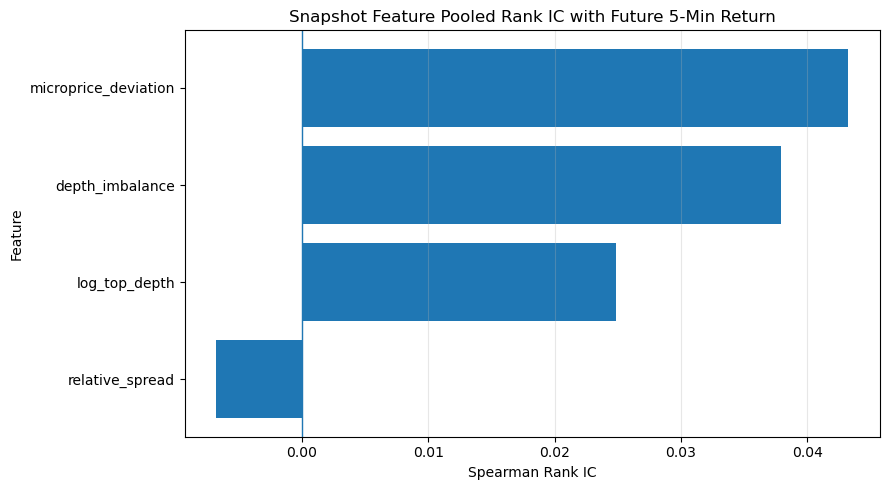

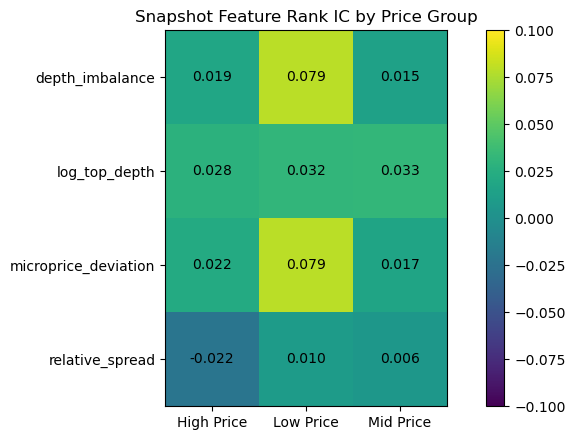

In [24]:
plot_rank_ic_bar(
    snapshot_eval["pooled_ic"],
    "Snapshot Feature Pooled Rank IC with Future 5-Min Return"
)

plot_price_group_ic(
    snapshot_eval["price_group_ic_pivot"],
    "Snapshot Feature Rank IC by Price Group"
)


### 8.2 Snapshot Feature Interpretation Template

Use the pooled and price-group IC tables together.

A feature should be classified as:

- **Robust Feature**: same sign across price groups and stable daily IC.
- **Price-Conditional Feature**: useful mainly in one or two price groups.
- **Regime-Dependent Feature**: sign changes across price groups.
- **Weak Feature**: low IC across pooled and grouped samples.

This prevents the pooled sample from hiding the effect of tick-size discreteness in low-priced stocks.


#### Interim Findings: Snapshot Features and Price-Level Effects

The initial label analysis shows that the structure of future 5-minute returns differs across stock price levels. Low-priced stocks have a substantially higher zero-return ratio, indicating stronger return discretization.

Snapshot feature evaluation nevertheless shows that directional order-book features contain predictive information. `microprice_deviation` and `depth_imbalance` have positive pooled Rank IC and relatively stable positive Daily IC, suggesting that stronger buy-side book pressure is associated with higher future 5-minute return rankings.

Price-group analysis further reveals that this relationship is heterogeneous across price levels. The predictive signal of `microprice_deviation` and `depth_imbalance` is substantially stronger in the Low Price group, while the signal is weaker in the Mid and High Price groups.

This result suggests that a higher zero-return ratio does not necessarily eliminate cross-sectional ranking information. Although low-priced stocks exhibit more discrete price movements, order-book pressure may still help rank their future returns.

However, the current sample contains only a limited number of stocks within each price group. The stronger Low Price IC may therefore reflect either a genuine price-regime effect or a stock-composition effect driven by a small number of individual stocks.

The next step is to decompose IC at the stock level and examine whether the Low Price signal is broadly shared across stocks or concentrated in a few names.

In [32]:
# ============================================================
# Stock-Level IC Decomposition
# ============================================================

stock_level_features = [
    "depth_imbalance",
    "microprice_deviation"
]

stock_ic_rows = []

for code, group_df in master_feature_df.groupby("code"):

    price_group = group_df["price_group"].iloc[0]

    for feature in stock_level_features:

        sub = group_df[
            [
                feature,
                "future_return_5m"
            ]
        ].dropna()

        if (
            len(sub) < 30
            or sub[feature].nunique() < 2
            or sub["future_return_5m"].nunique() < 2
        ):
            continue

        rank_ic = sub[feature].corr(
            sub["future_return_5m"],
            method="spearman"
        )

        stock_ic_rows.append({
            "code": code,
            "price_group": price_group,
            "feature": feature,
            "rank_ic": rank_ic,
            "abs_rank_ic": abs(rank_ic),
            "n_obs": len(sub)
        })


stock_level_ic_df = pd.DataFrame(stock_ic_rows)

display(
    stock_level_ic_df
    .sort_values(
        ["feature", "rank_ic"],
        ascending=[True, False]
    )
)

,code,price_group,feature,rank_ic,abs_rank_ic,n_obs
38,600880.SH,Low Price,depth_imbalance,0.145156,0.145156,554
34,600601.SH,Mid Price,depth_imbalance,0.142810,0.142810,556
10,300247.SZ,Low Price,depth_imbalance,0.131033,0.131033,572
30,600282.SH,Low Price,depth_imbalance,0.096993,0.096993,558
16,300338.SZ,Low Price,depth_imbalance,0.087187,0.087187,562
0,000570.SZ,Low Price,depth_imbalance,0.076260,0.076260,571
14,300327.SZ,High Price,depth_imbalance,0.069426,0.069426,572
2,000766.SZ,High Price,depth_imbalance,0.062518,0.062518,572
28,600168.SH,Low Price,depth_imbalance,0.048264,0.048264,557
32,600403.SH,Low Price,depth_imbalance,0.039609,0.039609,554


In [33]:
# ============================================================
# Stock-Level IC Summary by Price Group
# ============================================================

stock_ic_summary = (
    stock_level_ic_df
    .groupby(
        [
            "price_group",
            "feature"
        ],
        observed=True
    )
    .agg(
        n_stocks=(
            "code",
            "nunique"
        ),
        mean_stock_ic=(
            "rank_ic",
            "mean"
        ),
        median_stock_ic=(
            "rank_ic",
            "median"
        ),
        stock_ic_std=(
            "rank_ic",
            "std"
        ),
        positive_stock_ratio=(
            "rank_ic",
            lambda x: (x > 0).mean()
        ),
        max_stock_ic=(
            "rank_ic",
            "max"
        ),
        min_stock_ic=(
            "rank_ic",
            "min"
        )
    )
    .reset_index()
)


display(stock_ic_summary)

,price_group,feature,n_stocks,mean_stock_ic,median_stock_ic,stock_ic_std,positive_stock_ratio,max_stock_ic,min_stock_ic
0,High Price,depth_imbalance,8,0.017632,0.014664,0.034760,0.625,0.069426,-0.022135
1,High Price,microprice_deviation,8,0.022625,0.028884,0.038960,0.625,0.076379,-0.029614
2,Low Price,depth_imbalance,8,0.081037,0.081724,0.043083,1.000,0.145156,0.023796
3,Low Price,microprice_deviation,8,0.081729,0.083658,0.044341,1.000,0.143852,0.023452
4,Mid Price,depth_imbalance,8,0.012864,0.001692,0.060042,0.500,0.142810,-0.045884
5,Mid Price,microprice_deviation,8,0.015383,0.008730,0.051475,0.625,0.124158,-0.037700


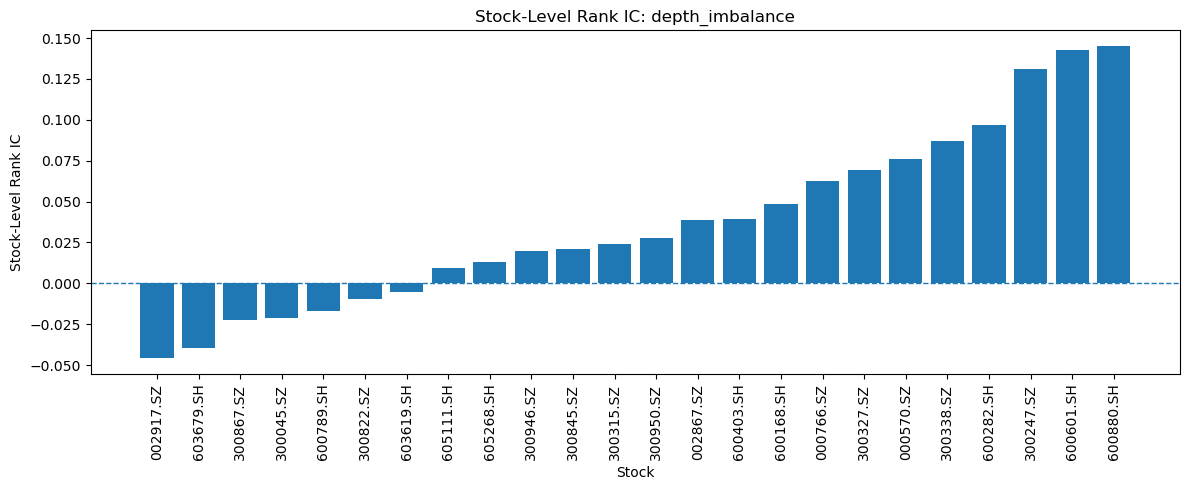

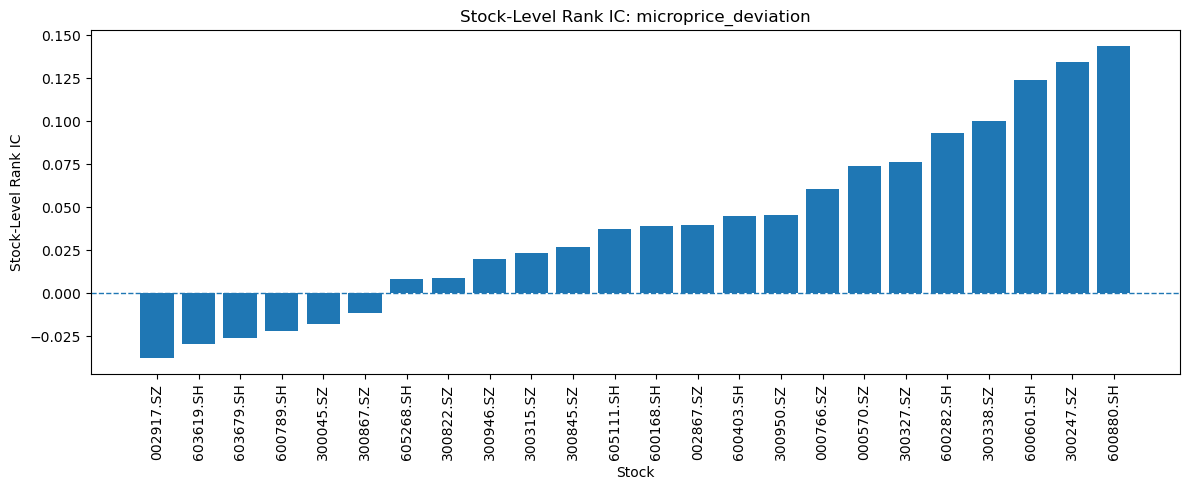

In [34]:
# ============================================================
# Stock-Level IC Distribution
# ============================================================

for feature in stock_level_features:

    plot_df = (
        stock_level_ic_df[
            stock_level_ic_df["feature"] == feature
        ]
        .sort_values("rank_ic")
        .copy()
    )

    plt.figure(figsize=(12, 5))

    x = np.arange(len(plot_df))

    plt.bar(
        x,
        plot_df["rank_ic"]
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.xticks(
        x,
        plot_df["code"],
        rotation=90
    )

    plt.xlabel("Stock")
    plt.ylabel("Stock-Level Rank IC")

    plt.title(
        f"Stock-Level Rank IC: {feature}"
    )

    plt.tight_layout()
    plt.show()

C:\Users\work\AppData\Local\Temp\ipykernel_26140\4065649081.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


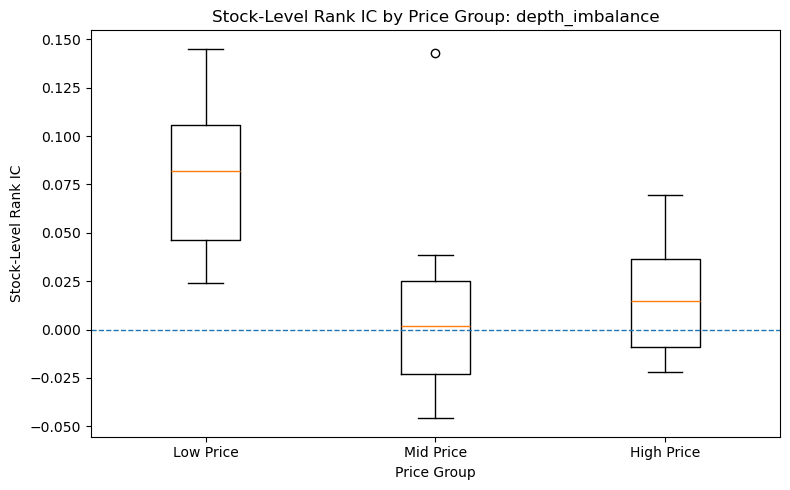

C:\Users\work\AppData\Local\Temp\ipykernel_26140\4065649081.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


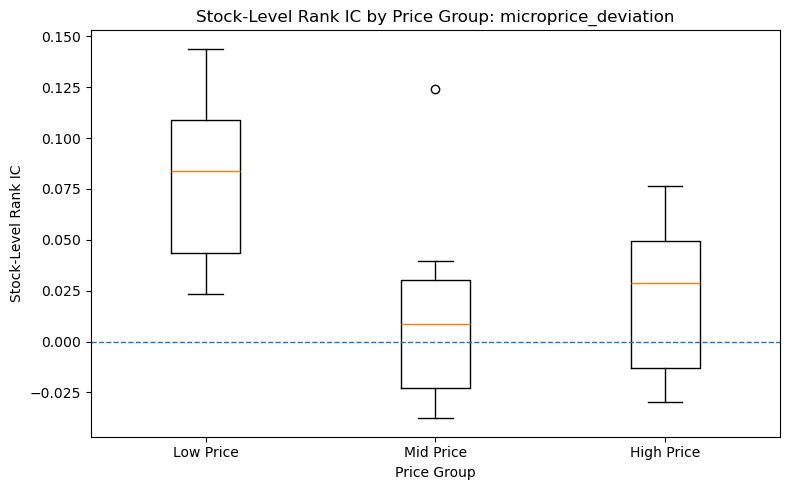

In [35]:
# ============================================================
# Stock-Level IC by Price Group
# ============================================================

for feature in stock_level_features:

    plot_df = stock_level_ic_df[
        stock_level_ic_df["feature"] == feature
    ].copy()

    price_order = [
        "Low Price",
        "Mid Price",
        "High Price"
    ]

    data = [
        plot_df.loc[
            plot_df["price_group"] == group,
            "rank_ic"
        ].dropna().values
        for group in price_order
    ]

    plt.figure(figsize=(8, 5))

    plt.boxplot(
        data,
        labels=price_order
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.xlabel("Price Group")
    plt.ylabel("Stock-Level Rank IC")

    plt.title(
        f"Stock-Level Rank IC by Price Group: {feature}"
    )

    plt.tight_layout()
    plt.show()

#### Stock-Level IC Decomposition

The stronger snapshot-feature IC observed in the Low Price group may arise either from a genuine price-regime pattern or from a small number of high-IC stocks. To distinguish these explanations, Rank IC is calculated separately for each stock.

The results show strong cross-stock consistency within the Low Price group. For both `depth_imbalance` and `microprice_deviation`, all eight low-priced stocks exhibit positive stock-level Rank IC. Mean and median stock-level IC are also nearly identical, suggesting that the group-level signal is not driven by a small number of extreme stocks.

In contrast, the Mid Price group shows substantially weaker consistency. Median stock-level IC is close to zero, while several high-IC stocks increase the group mean. This pattern suggests a stronger stock-composition effect.

The High Price group exhibits weak but moderately consistent positive relationships, although the signal is substantially smaller than that observed among low-priced stocks.

Overall, the current sample provides evidence that the stronger predictive relationship of directional order-book pressure among low-priced stocks is broadly shared across individual stocks rather than concentrated in a few names. This supports treating stock price level as a potentially important structural dimension in subsequent feature evaluation.

## 9. Trade Activity Features

Trade activity features describe recent trading intensity rather than current book shape.

This family asks:

```text
How active has trading been before time t?
```

Since `sum_volume` and `sum_amount` are cumulative fields, the notebook first recovers minute-level increments using first differences. Rolling windows then use only past and current observations.


In [25]:
trade_base = minute_panel.copy()
trade_base = trade_base.sort_values(["code", "date", "minute"]).reset_index(drop=True)

group_keys = ["code", "date"]

trade_base["minute_volume"] = trade_base.groupby(group_keys)["sum_volume"].diff()
trade_base["minute_turnover"] = trade_base.groupby(group_keys)["sum_amount"].diff()

display(
    trade_base[[
        "code", "date", "minute", "sum_volume", "minute_volume",
        "sum_amount", "minute_turnover"
    ]].head(10)
)

display(trade_base[["minute_volume", "minute_turnover"]].describe().T)


,code,date,minute,sum_volume,minute_volume,sum_amount,minute_turnover
0,000170.SH,2026-03-11,2026-03-11 09:30:00,758547,NaN,1.908851e+09,NaN
1,000170.SH,2026-03-11,2026-03-11 09:31:00,1235805,477258.0,3.336084e+09,1.427233e+09
2,000170.SH,2026-03-11,2026-03-11 09:32:00,1581843,346038.0,4.418654e+09,1.082570e+09
3,000170.SH,2026-03-11,2026-03-11 09:33:00,1914088,332245.0,5.582274e+09,1.163620e+09
4,000170.SH,2026-03-11,2026-03-11 09:34:00,2257022,342934.0,6.814830e+09,1.232556e+09
5,000170.SH,2026-03-11,2026-03-11 09:35:00,2680434,423412.0,7.751222e+09,9.363924e+08
6,000170.SH,2026-03-11,2026-03-11 09:36:00,2936945,256511.0,8.614606e+09,8.633843e+08
7,000170.SH,2026-03-11,2026-03-11 09:37:00,3153523,216578.0,9.487888e+09,8.732811e+08
8,000170.SH,2026-03-11,2026-03-11 09:38:00,3374159,220636.0,1.032280e+10,8.349100e+08
9,000170.SH,2026-03-11,2026-03-11 09:39:00,3610196,236037.0,1.120370e+10,8.809074e+08


,count,mean,std,min,25%,50%,75%,max
minute_volume,16297.0,1.829364e+05,3.233747e+05,0.0,28600.0,79800.0,207500.0,9.484174e+06
minute_turnover,16297.0,3.133630e+07,1.590195e+08,0.0,324621.0,885065.0,2580197.0,2.775879e+09


In [26]:
trade_base["volume_1m"] = trade_base["minute_volume"]
trade_base["turnover_1m"] = trade_base["minute_turnover"]

for window in [3, 5]:
    trade_base[f"volume_{window}m"] = (
        trade_base
        .groupby(group_keys)["minute_volume"]
        .transform(lambda x: x.rolling(window=window, min_periods=window).sum())
    )
    trade_base[f"turnover_{window}m"] = (
        trade_base
        .groupby(group_keys)["minute_turnover"]
        .transform(lambda x: x.rolling(window=window, min_periods=window).sum())
    )

trade_base["trade_intensity_5m"] = trade_base["volume_5m"] / 5

trade_base["previous_volume_3m"] = (
    trade_base
    .groupby(group_keys)["minute_volume"]
    .transform(lambda x: x.shift(3).rolling(window=3, min_periods=3).sum())
)

trade_base["volume_acceleration"] = (
    (trade_base["volume_3m"] - trade_base["previous_volume_3m"])
    / (trade_base["previous_volume_3m"].abs() + 1)
)

display(
    trade_base[[
        "code", "date", "minute", "minute_volume", "volume_3m",
        "previous_volume_3m", "volume_acceleration", "trade_intensity_5m"
    ]].head(15)
)


,code,date,minute,minute_volume,volume_3m,previous_volume_3m,volume_acceleration,trade_intensity_5m
0,000170.SH,2026-03-11,2026-03-11 09:30:00,NaN,NaN,NaN,NaN,NaN
1,000170.SH,2026-03-11,2026-03-11 09:31:00,477258.0,NaN,NaN,NaN,NaN
2,000170.SH,2026-03-11,2026-03-11 09:32:00,346038.0,NaN,NaN,NaN,NaN
3,000170.SH,2026-03-11,2026-03-11 09:33:00,332245.0,1155541.0,NaN,NaN,NaN
4,000170.SH,2026-03-11,2026-03-11 09:34:00,342934.0,1021217.0,NaN,NaN,NaN
5,000170.SH,2026-03-11,2026-03-11 09:35:00,423412.0,1098591.0,NaN,NaN,384377.4
6,000170.SH,2026-03-11,2026-03-11 09:36:00,256511.0,1022857.0,1155541.0,-0.114824,340228.0
7,000170.SH,2026-03-11,2026-03-11 09:37:00,216578.0,896501.0,1021217.0,-0.122125,314336.0
8,000170.SH,2026-03-11,2026-03-11 09:38:00,220636.0,693725.0,1098591.0,-0.368532,292014.2
9,000170.SH,2026-03-11,2026-03-11 09:39:00,236037.0,673251.0,1022857.0,-0.341793,270634.8


In [27]:
trade_candidate_features = [
    "volume_1m",
    "volume_3m",
    "volume_5m",
    "turnover_1m",
    "turnover_3m",
    "turnover_5m",
    "trade_intensity_5m",
    "volume_acceleration"
]

trade_feature_cols = ["code", "date", "minute"] + trade_candidate_features

master_feature_df = master_feature_df.merge(
    trade_base[trade_feature_cols],
    on=["code", "date", "minute"],
    how="left"
)

print("master_feature_df shape:", master_feature_df.shape)
display(
    master_feature_df[["code", "date", "minute", "price_group"] + trade_candidate_features + ["future_return_5m"]].head(12)
)


master_feature_df shape: (13518, 39)


,code,date,minute,price_group,volume_1m,volume_3m,volume_5m,turnover_1m,turnover_3m,turnover_5m,trade_intensity_5m,volume_acceleration,future_return_5m
0,000570.SZ,2026-03-11,2026-03-11 09:30:00,Low Price,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001586
1,000570.SZ,2026-03-11,2026-03-11 09:31:00,Low Price,299500.0,NaN,NaN,1888029.0,NaN,NaN,NaN,NaN,-0.002379
2,000570.SZ,2026-03-11,2026-03-11 09:32:00,Low Price,216500.0,NaN,NaN,1365388.0,NaN,NaN,NaN,NaN,0.001589
3,000570.SZ,2026-03-11,2026-03-11 09:33:00,Low Price,381900.0,897900.0,NaN,2394428.0,5647845.0,NaN,NaN,NaN,0.004789
4,000570.SZ,2026-03-11,2026-03-11 09:34:00,Low Price,359000.0,957400.0,NaN,2259229.0,6019045.0,NaN,NaN,NaN,-0.001589
5,000570.SZ,2026-03-11,2026-03-11 09:35:00,Low Price,1835500.0,2576400.0,3092400.0,11559773.0,16213430.0,19466847.0,618480.0,NaN,-0.006334
6,000570.SZ,2026-03-11,2026-03-11 09:36:00,Low Price,553400.0,2747900.0,3346300.0,3490925.0,17309927.0,21069743.0,669260.0,2.060361,-0.003975
7,000570.SZ,2026-03-11,2026-03-11 09:37:00,Low Price,866200.0,3255100.0,3996000.0,5452287.0,20502985.0,25156642.0,799200.0,2.399935,-0.007930
8,000570.SZ,2026-03-11,2026-03-11 09:38:00,Low Price,435100.0,1854700.0,4049200.0,2746554.0,11689766.0,25508768.0,809840.0,-0.280119,-0.004766
9,000570.SZ,2026-03-11,2026-03-11 09:39:00,Low Price,820800.0,2122100.0,4511000.0,5169478.0,13368319.0,28419017.0,902200.0,-0.227737,-0.004773


In [28]:
display(master_feature_df[trade_candidate_features].describe().T)

display(
    master_feature_df[trade_candidate_features]
    .isna()
    .mean()
    .rename("missing_rate")
    .to_frame()
)


,count,mean,std,min,25%,50%,75%,max
volume_1m,12992.0,1.947603e+05,3.480074e+05,0.000000,3.140000e+04,8.320000e+04,2.107412e+05,9.484174e+06
volume_3m,11939.0,5.687854e+05,9.045483e+05,1000.000000,1.181000e+05,2.672000e+05,6.224000e+05,1.992972e+07
volume_5m,10885.0,9.347308e+05,1.419523e+06,4300.000000,2.070000e+05,4.508000e+05,1.019900e+06,2.576112e+07
turnover_1m,12992.0,2.431825e+06,4.695816e+06,0.000000,3.581282e+05,9.077295e+05,2.457849e+06,9.001783e+07
turnover_3m,11939.0,7.072965e+06,1.237792e+07,7055.000000,1.252727e+06,2.887780e+06,7.401741e+06,1.824845e+08
turnover_5m,10885.0,1.157184e+07,1.927367e+07,53759.000000,2.161297e+06,4.815389e+06,1.237314e+07,2.356592e+08
trade_intensity_5m,10885.0,1.869462e+05,2.839045e+05,860.000000,4.140000e+04,9.016000e+04,2.039800e+05,5.152225e+06
volume_acceleration,10358.0,8.686824e-02,9.556810e-01,-0.975503,-3.909902e-01,-1.218539e-01,2.734098e-01,1.819131e+01


,missing_rate
volume_1m,0.038911
volume_3m,0.116807
volume_5m,0.194777
turnover_1m,0.038911
turnover_3m,0.116807
turnover_5m,0.194777
trade_intensity_5m,0.194777
volume_acceleration,0.233762


### 9.1 Trade Activity Feature Evaluation

Trade activity features are also evaluated using the same parallel framework:

- Pooled IC
- Daily IC stability
- Price-group IC
- Price-group daily IC stability


In [29]:
trade_eval = evaluate_feature_family(
    master_feature_df,
    trade_candidate_features,
    family_name="Trade Activity"
)

print("Pooled IC:")
display(trade_eval["pooled_ic"])

print("Daily IC Summary:")
display(trade_eval["daily_ic_summary"])

print("Price-Group Rank IC:")
display(trade_eval["price_group_ic_pivot"])

print("Price-Group Daily IC Summary:")
display(trade_eval["price_group_daily_summary"])


Pooled IC:


,family,feature,pearson_ic,rank_ic,abs_rank_ic,n_obs,signal_direction
0,Trade Activity,volume_acceleration,-0.006389,-0.026842,0.026842,10358,Negative
1,Trade Activity,turnover_5m,0.031242,0.021118,0.021118,10885,Positive
2,Trade Activity,turnover_3m,0.017595,0.016240,0.016240,11939,Positive
3,Trade Activity,volume_3m,0.005215,0.014949,0.014949,11939,Positive
4,Trade Activity,volume_5m,0.012399,0.013980,0.013980,10885,Positive
5,Trade Activity,trade_intensity_5m,0.012399,0.013980,0.013980,10885,Positive
6,Trade Activity,volume_1m,-0.000447,0.007216,0.007216,12992,Positive
7,Trade Activity,turnover_1m,-0.001955,0.003278,0.003278,12992,Positive


Daily IC Summary:


,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir,abs_mean_daily_ic
feature,,,,,,
turnover_5m,0.022944,0.118902,0.590909,22,0.192968,0.022944
volume_acceleration,-0.018696,0.091906,0.409091,22,-0.203423,0.018696
turnover_3m,0.016587,0.118560,0.500000,22,0.139906,0.016587
trade_intensity_5m,0.013033,0.102775,0.545455,22,0.126814,0.013033
volume_5m,0.013033,0.102775,0.545455,22,0.126814,0.013033
volume_3m,0.012113,0.095592,0.454545,22,0.126720,0.012113
volume_1m,0.005668,0.087114,0.500000,22,0.065063,0.005668
turnover_1m,0.004939,0.109740,0.454545,22,0.045005,0.004939


Price-Group Rank IC:


price_group,High Price,Low Price,Mid Price
feature,,,
trade_intensity_5m,0.019326,0.004194,0.039636
turnover_1m,-0.003157,0.006266,0.016396
turnover_3m,0.012894,0.005590,0.033708
turnover_5m,0.015839,0.002778,0.036641
volume_1m,-0.000168,0.005939,0.019477
volume_3m,0.016646,0.006197,0.035099
volume_5m,0.019326,0.004194,0.039636
volume_acceleration,-0.039617,-0.035983,-0.005922


Price-Group Daily IC Summary:


,price_group,feature,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir
0,High Price,trade_intensity_5m,0.024284,0.131240,0.545455,22,0.185033
1,High Price,turnover_1m,-0.012099,0.115690,0.500000,22,-0.104585
2,High Price,turnover_3m,0.008756,0.135033,0.500000,22,0.064844
3,High Price,turnover_5m,0.020420,0.138374,0.500000,22,0.147573
4,High Price,volume_1m,-0.011215,0.111757,0.500000,22,-0.100348
5,High Price,volume_3m,0.012460,0.128256,0.545455,22,0.097146
6,High Price,volume_5m,0.024284,0.131240,0.545455,22,0.185033
7,High Price,volume_acceleration,-0.034391,0.116389,0.409091,22,-0.295486
8,Low Price,trade_intensity_5m,0.019945,0.152982,0.681818,22,0.130373
9,Low Price,turnover_1m,0.016552,0.136499,0.636364,22,0.121259


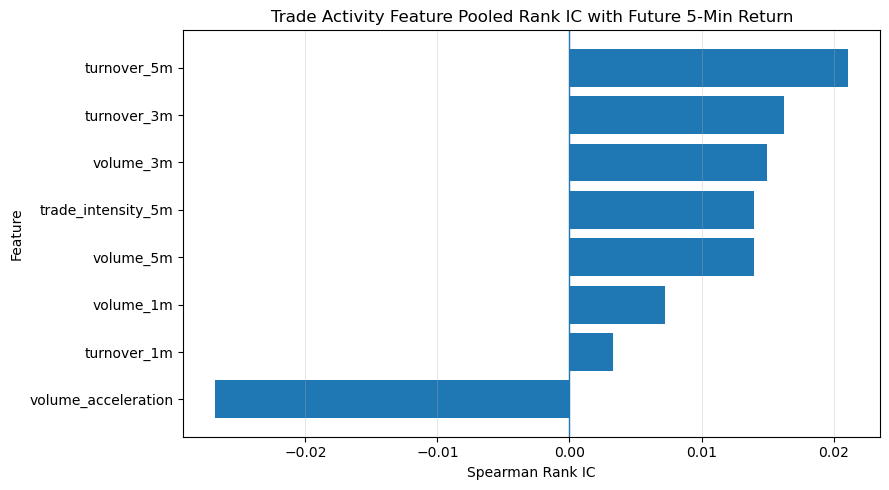

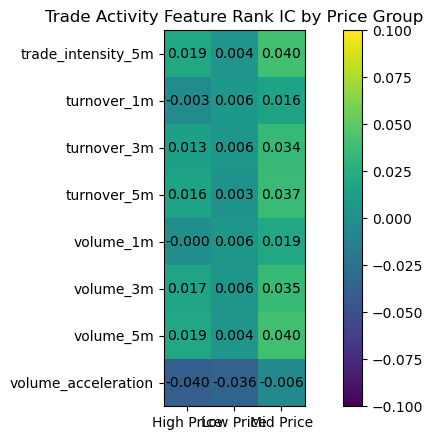

In [30]:
plot_rank_ic_bar(
    trade_eval["pooled_ic"],
    "Trade Activity Feature Pooled Rank IC with Future 5-Min Return"
)

plot_price_group_ic(
    trade_eval["price_group_ic_pivot"],
    "Trade Activity Feature Rank IC by Price Group"
)


#### Interim Findings: Trade Activity Features

Trade activity features exhibit substantially weaker predictive relationships than directional snapshot features. Raw volume and turnover measures show small pooled Rank IC and low Daily IC stability, suggesting that trading intensity alone provides limited information about the direction of future 5-minute returns.

Price-group analysis reveals a weak conditional pattern. Volume and turnover features show relatively stronger positive IC among Mid Price stocks, while the relationship is close to zero in the Low Price group. However, the Mid Price signal remains temporally unstable, with high Daily IC dispersion and low ICIR.

`volume_acceleration` exhibits a weak negative relationship in the Low and High Price groups, potentially indicating a short-term activity-shock or exhaustion effect. Further feature evaluation is required before interpreting this pattern as a reversal signal.

In addition, `trade_intensity_5m` is rank-equivalent to `volume_5m` and therefore provides no incremental information.

Overall, raw trading activity is not a strong standalone directional signal. Subsequent analysis should focus on signed trading pressure and order-flow direction rather than activity magnitude alone.

## 10. Signed Trading Pressure Features

### Research Motivation

Raw trading activity measures how much trading occurs, but it does not identify which side of the market is driving the activity.

For example, high trading volume may result from aggressive buying, aggressive selling, or intense two-sided trading. Therefore, volume alone contains limited information about the direction of future price movements.

Signed trading pressure introduces a directional component into trading activity:

```text
Buyer-side pressure  → Positive
Seller-side pressure → Negative

Last Price ≥ Best Ask
→ Buyer-pressure proxy (+1)

Last Price ≤ Best Bid
→ Seller-pressure proxy (-1)

Inside the spread
→ Ambiguous pressure (0)

In [41]:
if "minute_volume" not in master_feature_df.columns:
    master_feature_df = master_feature_df.merge(
        trade_base[
            [
                "code",
                "date",
                "minute",
                "minute_volume",
                "volume_1m",
                "volume_3m",
                "volume_5m",
                "turnover_1m",
                "turnover_3m",
                "turnover_5m",
                "volume_acceleration"
            ]
        ],
        on=["code", "date", "minute"],
        how="left"
    )

In [42]:
# ============================================================
# Signed Trading Pressure Features
# ============================================================

# Start from master feature table
# master_feature_df should already contain:
# code, date, minute, mid_price, bp0, ap0, last_price,
# minute_volume, future_return_5m, price_group

master_feature_df = master_feature_df.sort_values(
    ["code", "date", "minute"]
).reset_index(drop=True)


# ------------------------------------------------------------
# Trade sign proxy
#
# +1: last price at or above ask -> buyer-initiated proxy
# -1: last price at or below bid -> seller-initiated proxy
#  0: ambiguous / inside spread
# ------------------------------------------------------------

master_feature_df["trade_sign_proxy"] = np.select(
    [
        master_feature_df["last_price"] >= master_feature_df["ap0"],
        master_feature_df["last_price"] <= master_feature_df["bp0"]
    ],
    [
        1,
        -1
    ],
    default=0
)


# ------------------------------------------------------------
# Signed minute volume
# ------------------------------------------------------------

master_feature_df["signed_volume_1m"] = (
    master_feature_df["trade_sign_proxy"]
    * master_feature_df["minute_volume"]
)


display(
    master_feature_df[
        [
            "code",
            "date",
            "minute",
            "last_price",
            "bp0",
            "ap0",
            "trade_sign_proxy",
            "minute_volume",
            "signed_volume_1m"
        ]
    ].head(15)
)

,code,date,minute,last_price,bp0,ap0,trade_sign_proxy,minute_volume,signed_volume_1m
0,000570.SZ,2026-03-11,2026-03-11 09:30:00,6.31,6.30,6.31,1,NaN,NaN
1,000570.SZ,2026-03-11,2026-03-11 09:31:00,6.30,6.30,6.31,-1,299500.0,-299500.0
2,000570.SZ,2026-03-11,2026-03-11 09:32:00,6.29,6.29,6.30,-1,216500.0,-216500.0
3,000570.SZ,2026-03-11,2026-03-11 09:33:00,6.26,6.26,6.27,-1,381900.0,-381900.0
4,000570.SZ,2026-03-11,2026-03-11 09:34:00,6.29,6.29,6.30,-1,359000.0,-359000.0
5,000570.SZ,2026-03-11,2026-03-11 09:35:00,6.31,6.31,6.32,-1,1835500.0,-1835500.0
6,000570.SZ,2026-03-11,2026-03-11 09:36:00,6.29,6.28,6.30,0,553400.0,0.0
7,000570.SZ,2026-03-11,2026-03-11 09:37:00,6.31,6.30,6.31,1,866200.0,866200.0
8,000570.SZ,2026-03-11,2026-03-11 09:38:00,6.30,6.29,6.30,1,435100.0,435100.0
9,000570.SZ,2026-03-11,2026-03-11 09:39:00,6.29,6.28,6.29,1,820800.0,820800.0


In [43]:
# ============================================================
# Rolling Signed Trading Pressure
# ============================================================

group_keys = ["code", "date"]

for window in [3, 5]:

    master_feature_df[f"signed_volume_{window}m"] = (
        master_feature_df
        .groupby(group_keys)["signed_volume_1m"]
        .transform(
            lambda x: x.rolling(
                window=window,
                min_periods=window
            ).sum()
        )
    )

    master_feature_df[f"abs_volume_{window}m"] = (
        master_feature_df
        .groupby(group_keys)["minute_volume"]
        .transform(
            lambda x: x.rolling(
                window=window,
                min_periods=window
            ).sum()
        )
    )


# ------------------------------------------------------------
# Signed volume imbalance ratios
# ------------------------------------------------------------

master_feature_df["signed_volume_imbalance_1m"] = (
    master_feature_df["signed_volume_1m"]
    / (
        master_feature_df["minute_volume"].abs()
        + 1
    )
)

for window in [3, 5]:

    master_feature_df[f"signed_volume_imbalance_{window}m"] = (
        master_feature_df[f"signed_volume_{window}m"]
        / (
            master_feature_df[f"abs_volume_{window}m"].abs()
            + 1
        )
    )


signed_pressure_features = [
    "trade_sign_proxy",
    "signed_volume_1m",
    "signed_volume_3m",
    "signed_volume_5m",
    "signed_volume_imbalance_1m",
    "signed_volume_imbalance_3m",
    "signed_volume_imbalance_5m"
]


display(
    master_feature_df[
        [
            "code",
            "date",
            "minute"
        ]
        + signed_pressure_features
        + [
            "future_return_5m",
            "price_group"
        ]
    ].head(15)
)

,code,date,minute,trade_sign_proxy,signed_volume_1m,signed_volume_3m,signed_volume_5m,signed_volume_imbalance_1m,signed_volume_imbalance_3m,signed_volume_imbalance_5m,future_return_5m,price_group
0,000570.SZ,2026-03-11,2026-03-11 09:30:00,1,NaN,NaN,NaN,NaN,NaN,NaN,0.001586,Low Price
1,000570.SZ,2026-03-11,2026-03-11 09:31:00,-1,-299500.0,NaN,NaN,-0.999997,NaN,NaN,-0.002379,Low Price
2,000570.SZ,2026-03-11,2026-03-11 09:32:00,-1,-216500.0,NaN,NaN,-0.999995,NaN,NaN,0.001589,Low Price
3,000570.SZ,2026-03-11,2026-03-11 09:33:00,-1,-381900.0,-897900.0,NaN,-0.999997,-0.999999,NaN,0.004789,Low Price
4,000570.SZ,2026-03-11,2026-03-11 09:34:00,-1,-359000.0,-957400.0,NaN,-0.999997,-0.999999,NaN,-0.001589,Low Price
5,000570.SZ,2026-03-11,2026-03-11 09:35:00,-1,-1835500.0,-2576400.0,-3092400.0,-0.999999,-1.000000,-1.000000,-0.006334,Low Price
6,000570.SZ,2026-03-11,2026-03-11 09:36:00,0,0.0,-2194500.0,-2792900.0,0.000000,-0.798610,-0.834623,-0.003975,Low Price
7,000570.SZ,2026-03-11,2026-03-11 09:37:00,1,866200.0,-969300.0,-1710200.0,0.999999,-0.297779,-0.427978,-0.007930,Low Price
8,000570.SZ,2026-03-11,2026-03-11 09:38:00,1,435100.0,1301300.0,-893200.0,0.999998,0.701623,-0.220587,-0.004766,Low Price
9,000570.SZ,2026-03-11,2026-03-11 09:39:00,1,820800.0,2122100.0,286600.0,0.999999,1.000000,0.063534,-0.004773,Low Price


In [44]:
# ============================================================
# Signed Pressure Feature Diagnostics
# ============================================================

display(
    master_feature_df[
        signed_pressure_features
    ].describe().T
)

display(
    master_feature_df[
        signed_pressure_features
    ]
    .isna()
    .mean()
    .rename("missing_rate")
    .to_frame()
)

,count,mean,std,min,25%,50%,75%,max
trade_sign_proxy,13518.0,0.009543,0.968994,-1.0,-1.000000,0.000000,1.000000,1.0
signed_volume_1m,12992.0,1378.353063,395639.446946,-7657300.0,-74700.000000,0.000000,80295.500000,9484174.0
signed_volume_3m,11938.0,-1399.618278,666901.677436,-15348425.0,-108764.500000,800.000000,118700.000000,8623300.0
signed_volume_5m,10884.0,-3870.016814,862758.577952,-14896725.0,-144700.000000,155.000000,152925.000000,13760625.0
signed_volume_imbalance_1m,12992.0,0.008466,0.967483,-1.0,-0.999987,0.000000,0.999988,1.0
signed_volume_imbalance_3m,11938.0,0.002178,0.627009,-1.0,-0.493494,0.006722,0.491885,1.0
signed_volume_imbalance_5m,10884.0,-0.001458,0.510536,-1.0,-0.379954,0.000519,0.383747,1.0


,missing_rate
trade_sign_proxy,0.000000
signed_volume_1m,0.038911
signed_volume_3m,0.116881
signed_volume_5m,0.194851
signed_volume_imbalance_1m,0.038911
signed_volume_imbalance_3m,0.116881
signed_volume_imbalance_5m,0.194851


In [45]:
# ============================================================
# Pooled IC: Signed Trading Pressure Features
# ============================================================

signed_pooled_rows = []

for feature in signed_pressure_features:

    sub = master_feature_df[
        [
            feature,
            "future_return_5m"
        ]
    ].dropna()

    if (
        len(sub) < 20
        or sub[feature].nunique() < 2
        or sub["future_return_5m"].nunique() < 2
    ):
        continue

    pearson_ic = sub[feature].corr(
        sub["future_return_5m"],
        method="pearson"
    )

    rank_ic = sub[feature].corr(
        sub["future_return_5m"],
        method="spearman"
    )

    signed_pooled_rows.append({
        "family": "Signed Trading Pressure",
        "feature": feature,
        "pearson_ic": pearson_ic,
        "rank_ic": rank_ic,
        "abs_rank_ic": abs(rank_ic),
        "n_obs": len(sub),
        "signal_direction": (
            "Positive"
            if rank_ic > 0
            else "Negative"
        )
    })


signed_pooled_ic = (
    pd.DataFrame(signed_pooled_rows)
    .sort_values(
        "abs_rank_ic",
        ascending=False
    )
    .reset_index(drop=True)
)

display(signed_pooled_ic)

,family,feature,pearson_ic,rank_ic,abs_rank_ic,n_obs,signal_direction
0,Signed Trading Pressure,signed_volume_3m,0.022505,0.031984,0.031984,11938,Positive
1,Signed Trading Pressure,trade_sign_proxy,0.019678,0.028579,0.028579,13518,Positive
2,Signed Trading Pressure,signed_volume_1m,0.026631,0.028123,0.028123,12992,Positive
3,Signed Trading Pressure,signed_volume_imbalance_1m,0.021715,0.028123,0.028123,12992,Positive
4,Signed Trading Pressure,signed_volume_imbalance_3m,0.016475,0.023768,0.023768,11938,Positive
5,Signed Trading Pressure,signed_volume_5m,0.015188,0.014612,0.014612,10884,Positive
6,Signed Trading Pressure,signed_volume_imbalance_5m,0.004621,0.004617,0.004617,10884,Positive


In [46]:
# ============================================================
# Daily IC: Signed Trading Pressure Features
# ============================================================

signed_daily_rows = []

for date, date_df in master_feature_df.groupby("date"):

    for feature in signed_pressure_features:

        sub = date_df[
            [
                feature,
                "future_return_5m"
            ]
        ].dropna()

        if (
            len(sub) < 20
            or sub[feature].nunique() < 2
            or sub["future_return_5m"].nunique() < 2
        ):
            continue

        rank_ic = sub[feature].corr(
            sub["future_return_5m"],
            method="spearman"
        )

        signed_daily_rows.append({
            "date": date,
            "feature": feature,
            "rank_ic": rank_ic
        })


signed_daily_ic = pd.DataFrame(signed_daily_rows)

signed_daily_ic_summary = (
    signed_daily_ic
    .groupby("feature")
    .agg(
        mean_daily_ic=("rank_ic", "mean"),
        ic_std=("rank_ic", "std"),
        positive_ic_ratio=(
            "rank_ic",
            lambda x: (x > 0).mean()
        ),
        n_days=("rank_ic", "count")
    )
)

signed_daily_ic_summary["icir"] = (
    signed_daily_ic_summary["mean_daily_ic"]
    / signed_daily_ic_summary["ic_std"]
)

signed_daily_ic_summary["abs_mean_daily_ic"] = (
    signed_daily_ic_summary["mean_daily_ic"].abs()
)

signed_daily_ic_summary = (
    signed_daily_ic_summary
    .sort_values(
        "abs_mean_daily_ic",
        ascending=False
    )
)

display(signed_daily_ic_summary)

,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir,abs_mean_daily_ic
feature,,,,,,
signed_volume_imbalance_5m,-0.027413,0.090724,0.363636,22,-0.302160,0.027413
trade_sign_proxy,0.017970,0.054864,0.681818,22,0.327540,0.017970
signed_volume_5m,-0.015255,0.104249,0.409091,22,-0.146336,0.015255
signed_volume_1m,0.014988,0.060773,0.590909,22,0.246631,0.014988
signed_volume_imbalance_1m,0.014988,0.060773,0.590909,22,0.246631,0.014988
signed_volume_3m,0.006269,0.093731,0.454545,22,0.066886,0.006269
signed_volume_imbalance_3m,-0.003087,0.086445,0.454545,22,-0.035714,0.003087


In [47]:
# ============================================================
# Price-Group IC: Signed Trading Pressure Features
# ============================================================

signed_price_group_rows = []

for price_group, group_df in master_feature_df.groupby(
    "price_group",
    observed=True
):

    for feature in signed_pressure_features:

        sub = group_df[
            [
                feature,
                "future_return_5m"
            ]
        ].dropna()

        if (
            len(sub) < 20
            or sub[feature].nunique() < 2
            or sub["future_return_5m"].nunique() < 2
        ):
            continue

        rank_ic = sub[feature].corr(
            sub["future_return_5m"],
            method="spearman"
        )

        signed_price_group_rows.append({
            "price_group": price_group,
            "feature": feature,
            "rank_ic": rank_ic,
            "abs_rank_ic": abs(rank_ic),
            "n_obs": len(sub)
        })


signed_price_group_ic = pd.DataFrame(
    signed_price_group_rows
)

signed_price_group_rank_ic = (
    signed_price_group_ic
    .pivot(
        index="feature",
        columns="price_group",
        values="rank_ic"
    )
)

display(signed_price_group_rank_ic)

price_group,High Price,Low Price,Mid Price
feature,,,
signed_volume_1m,0.004263,0.059374,0.004853
signed_volume_3m,0.031159,0.055598,-0.001367
signed_volume_5m,0.021299,0.037986,-0.029235
signed_volume_imbalance_1m,0.004263,0.059374,0.004853
signed_volume_imbalance_3m,0.026186,0.052740,-0.013013
signed_volume_imbalance_5m,0.020746,0.025808,-0.042157
trade_sign_proxy,0.006412,0.066316,0.011015


In [48]:
# ============================================================
# Price-Group Daily IC: Signed Trading Pressure Features
# ============================================================

signed_pg_daily_rows = []

for (price_group, date), group_df in master_feature_df.groupby(
    [
        "price_group",
        "date"
    ],
    observed=True
):

    for feature in signed_pressure_features:

        sub = group_df[
            [
                feature,
                "future_return_5m"
            ]
        ].dropna()

        if (
            len(sub) < 10
            or sub[feature].nunique() < 2
            or sub["future_return_5m"].nunique() < 2
        ):
            continue

        rank_ic = sub[feature].corr(
            sub["future_return_5m"],
            method="spearman"
        )

        signed_pg_daily_rows.append({
            "price_group": price_group,
            "date": date,
            "feature": feature,
            "rank_ic": rank_ic
        })


signed_pg_daily_ic = pd.DataFrame(
    signed_pg_daily_rows
)

signed_pg_daily_ic_summary = (
    signed_pg_daily_ic
    .groupby(
        [
            "price_group",
            "feature"
        ],
        observed=True
    )
    .agg(
        mean_daily_ic=("rank_ic", "mean"),
        ic_std=("rank_ic", "std"),
        positive_ic_ratio=(
            "rank_ic",
            lambda x: (x > 0).mean()
        ),
        n_days=("rank_ic", "count")
    )
    .reset_index()
)

signed_pg_daily_ic_summary["icir"] = (
    signed_pg_daily_ic_summary["mean_daily_ic"]
    / signed_pg_daily_ic_summary["ic_std"]
)

display(signed_pg_daily_ic_summary)

,price_group,feature,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir
0,High Price,signed_volume_1m,-0.007200,0.074276,0.454545,22,-0.096935
1,High Price,signed_volume_3m,0.003848,0.102066,0.500000,22,0.037699
2,High Price,signed_volume_5m,-0.016250,0.142513,0.363636,22,-0.114024
3,High Price,signed_volume_imbalance_1m,-0.007200,0.074276,0.454545,22,-0.096935
4,High Price,signed_volume_imbalance_3m,0.000722,0.089809,0.500000,22,0.008036
5,High Price,signed_volume_imbalance_5m,-0.018669,0.111258,0.272727,22,-0.167803
6,High Price,trade_sign_proxy,-0.000229,0.063490,0.454545,22,-0.003606
7,Low Price,signed_volume_1m,0.031574,0.093199,0.636364,22,0.338781
8,Low Price,signed_volume_3m,0.015426,0.143630,0.454545,22,0.107401
9,Low Price,signed_volume_5m,-0.013663,0.166451,0.454545,22,-0.082085


#### Signed Trading Pressure Findings

Signed trading-pressure features provide stronger directional information than raw trading activity. `signed_volume_3m`, `trade_sign_proxy`, and `signed_volume_1m` exhibit higher pooled Rank IC than the corresponding unsigned volume features, suggesting that trading direction is more informative than trading magnitude alone.

However, the signed-pressure signal remains less temporally stable than the previously examined snapshot order-book features. Snapshot measures such as `depth_imbalance` and `microprice_deviation` continue to exhibit higher Daily IC and ICIR.

The predictive relationship is strongly price-dependent. Short-horizon signed pressure is substantially stronger among Low Price stocks. In particular, `trade_sign_proxy` and `signed_volume_1m` show the strongest positive relationships in this group.

The strength of the signal generally declines as the rolling window increases from the current trading direction to 1-minute, 3-minute, and 5-minute signed pressure. This suggests that directional trading information may decay quickly at short horizons.

The Mid Price group exhibits a different pattern. Longer-window signed pressure becomes negatively associated with future returns, particularly for the 5-minute normalized pressure measure. This may indicate a potential pressure-exhaustion or short-horizon reversal pattern, although the relationship remains temporally unstable.

Overall, the results suggest that short-horizon directional trading pressure contains more predictive information than raw trading activity. However, the current trade-signing methodology remains an approximation and motivates the construction of more precise aggressor-side order-flow features.

### 11. Price Momentum Features

Price momentum features describe the recent direction of price movement before time \(t\).

This feature family asks:

> Does recent price movement contain information about the next 5-minute return?

Three backward-looking return windows are constructed:

| Feature | Definition | Interpretation |
|---|---|---|
| `return_1m` | Mid-price return over the previous 1 minute | Very short-term price movement |
| `return_3m` | Mid-price return over the previous 3 minutes | Short-term price trend |
| `return_5m` | Mid-price return over the previous 5 minutes | Medium short-horizon momentum |

All momentum features use only information observable at or before time \(t\).

The main empirical question is whether recent price movements exhibit:

- **Momentum**: positive past returns predict positive future returns.
- **Reversal**: positive past returns predict negative future returns.

The analysis continues to distinguish Low-, Mid-, and High-Price stocks because tick-size discreteness may affect short-horizon return dynamics.

In [49]:
# ============================================================
# Price Momentum Features
# ============================================================

master_feature_df = (
    master_feature_df
    .sort_values(["code", "date", "minute"])
    .reset_index(drop=True)
)

group_keys = ["code", "date"]

for window in [1, 3, 5]:
    master_feature_df[f"return_{window}m"] = (
        master_feature_df["mid_price"]
        / master_feature_df.groupby(group_keys)["mid_price"].shift(window)
        - 1
    )

momentum_candidate_features = [
    "return_1m",
    "return_3m",
    "return_5m"
]

display(
    master_feature_df[
        [
            "code",
            "date",
            "minute",
            "mid_price",
            "price_group"
        ]
        + momentum_candidate_features
        + ["future_return_5m"]
    ].head(15)
)

,code,date,minute,mid_price,price_group,return_1m,return_3m,return_5m,future_return_5m
0,000570.SZ,2026-03-11,2026-03-11 09:30:00,6.305,Low Price,NaN,NaN,NaN,0.001586
1,000570.SZ,2026-03-11,2026-03-11 09:31:00,6.305,Low Price,0.000000,NaN,NaN,-0.002379
2,000570.SZ,2026-03-11,2026-03-11 09:32:00,6.295,Low Price,-0.001586,NaN,NaN,0.001589
3,000570.SZ,2026-03-11,2026-03-11 09:33:00,6.265,Low Price,-0.004766,-0.006344,NaN,0.004789
4,000570.SZ,2026-03-11,2026-03-11 09:34:00,6.295,Low Price,0.004789,-0.001586,NaN,-0.001589
5,000570.SZ,2026-03-11,2026-03-11 09:35:00,6.315,Low Price,0.003177,0.003177,0.001586,-0.006334
6,000570.SZ,2026-03-11,2026-03-11 09:36:00,6.290,Low Price,-0.003959,0.003990,-0.002379,-0.003975
7,000570.SZ,2026-03-11,2026-03-11 09:37:00,6.305,Low Price,0.002385,0.001589,0.001589,-0.007930
8,000570.SZ,2026-03-11,2026-03-11 09:38:00,6.295,Low Price,-0.001586,-0.003167,0.004789,-0.004766
9,000570.SZ,2026-03-11,2026-03-11 09:39:00,6.285,Low Price,-0.001589,-0.000795,-0.001589,-0.004773


In [50]:
# ============================================================
# Momentum Feature Diagnostics
# ============================================================

display(
    master_feature_df[
        momentum_candidate_features
    ].describe().T
)

momentum_missing = (
    master_feature_df[
        momentum_candidate_features
    ]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .to_frame()
)

display(momentum_missing)

,count,mean,std,min,25%,50%,75%,max
return_1m,12991.0,-0.000030,0.002850,-0.038431,-0.001570,0.0,0.001240,0.064729
return_3m,11937.0,-0.000127,0.004729,-0.059105,-0.002296,0.0,0.002039,0.138417
return_5m,10883.0,-0.000229,0.005925,-0.076274,-0.003243,0.0,0.002327,0.130449


,missing_rate
return_5m,0.194925
return_3m,0.116955
return_1m,0.038985


Momentum features are evaluated using the same parallel IC framework as the previous feature families:

1. Pooled IC
2. Daily IC stability
3. Price-group IC
4. Price-group daily IC stability

The sign of Rank IC provides a direct interpretation:

```text
Positive Rank IC
→ Higher past return
→ Higher future 5-minute return
→ Momentum

Negative Rank IC
→ Higher past return
→ Lower future 5-minute return
→ Reversal

In [51]:
# ============================================================
# Momentum Feature Evaluation
# ============================================================

momentum_eval = evaluate_feature_family(
    master_feature_df,
    momentum_candidate_features,
    family_name="Price Momentum"
)

print("Pooled IC:")
display(momentum_eval["pooled_ic"])

print("Daily IC Summary:")
display(momentum_eval["daily_ic_summary"])

print("Price-Group Rank IC:")
display(momentum_eval["price_group_ic_pivot"])

print("Price-Group Daily IC Summary:")
display(momentum_eval["price_group_daily_summary"])

Pooled IC:


,family,feature,pearson_ic,rank_ic,abs_rank_ic,n_obs,signal_direction
0,Price Momentum,return_5m,-0.110266,-0.039335,0.039335,10883,Negative
1,Price Momentum,return_3m,-0.091950,-0.037460,0.037460,11937,Negative
2,Price Momentum,return_1m,-0.061632,-0.032657,0.032657,12991,Negative


Daily IC Summary:


,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir,abs_mean_daily_ic
feature,,,,,,
return_5m,-0.128345,0.131373,0.181818,22,-0.976950,0.128345
return_3m,-0.105694,0.129810,0.181818,22,-0.814223,0.105694
return_1m,-0.073073,0.068561,0.181818,22,-1.065804,0.073073


Price-Group Rank IC:


price_group,High Price,Low Price,Mid Price
feature,,,
return_1m,-0.050600,-0.028788,-0.020818
return_3m,-0.071141,-0.026949,-0.013698
return_5m,-0.080369,-0.016407,-0.021945


Price-Group Daily IC Summary:


,price_group,feature,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir
0,High Price,return_1m,-0.084347,0.090983,0.136364,22,-0.927069
1,High Price,return_3m,-0.130308,0.147580,0.181818,22,-0.882968
2,High Price,return_5m,-0.163413,0.151593,0.136364,22,-1.077968
3,Low Price,return_1m,-0.092402,0.096449,0.181818,22,-0.958042
4,Low Price,return_3m,-0.143042,0.147357,0.181818,22,-0.970721
5,Low Price,return_5m,-0.163835,0.162972,0.181818,22,-1.005291
6,Mid Price,return_1m,-0.062573,0.083098,0.181818,22,-0.753005
7,Mid Price,return_3m,-0.072544,0.173490,0.318182,22,-0.418145
8,Mid Price,return_5m,-0.103582,0.183324,0.272727,22,-0.565021


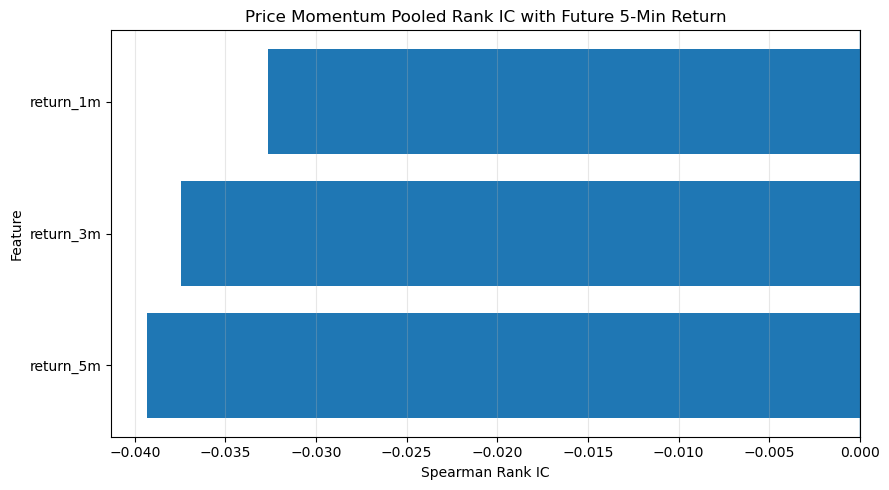

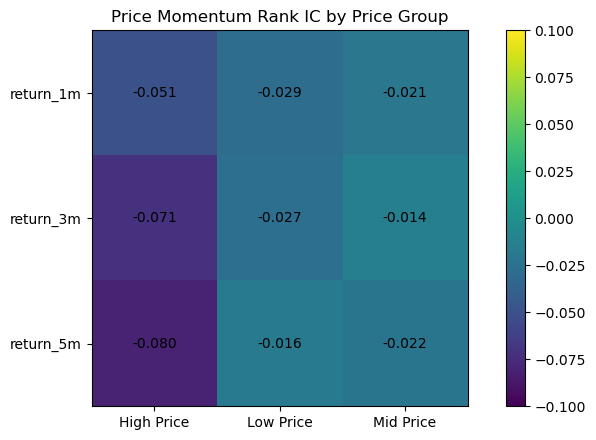

In [52]:
# ============================================================
# Momentum Feature IC Visualization
# ============================================================

plot_rank_ic_bar(
    momentum_eval["pooled_ic"],
    "Price Momentum Pooled Rank IC with Future 5-Min Return"
)

plot_price_group_ic(
    momentum_eval["price_group_ic_pivot"],
    "Price Momentum Rank IC by Price Group"
)

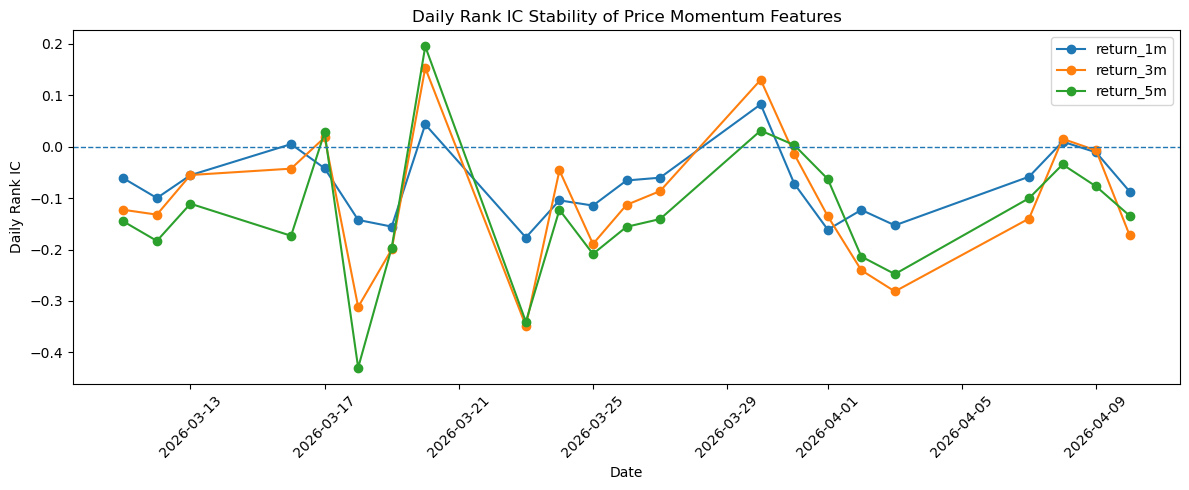

In [53]:
# ============================================================
# Daily Rank IC Stability of Momentum Features
# ============================================================

momentum_daily_ic = momentum_eval["daily_ic"]

plt.figure(figsize=(12, 5))

for feature in momentum_candidate_features:
    feature_ic = momentum_daily_ic[
        momentum_daily_ic["feature"] == feature
    ]

    plt.plot(
        feature_ic["date"],
        feature_ic["rank_ic"],
        marker="o",
        label=feature
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Daily Rank IC Stability of Price Momentum Features"
)

plt.xlabel("Date")
plt.ylabel("Daily Rank IC")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

#### Price Momentum Findings

Price momentum features exhibit a clear negative relationship with future 5-minute returns, indicating short-term price reversal rather than momentum.

Across the pooled sample, all backward-looking return features have negative Rank IC. The reversal relationship becomes slightly stronger as the lookback horizon increases from 1 minute to 5 minutes.

Daily IC analysis provides stronger evidence of signal stability. The mean daily IC is negative for all three momentum horizons, while positive IC ratios are only approximately 18%. This suggests that the reversal relationship is observed on most trading days rather than being driven by a small number of extreme observations.

The 5-minute historical return shows the strongest reversal signal, with a mean daily IC of approximately -0.13 and an ICIR close to -1.

Price-group decomposition shows that reversal exists across Low-, Mid-, and High-Price stocks. However, the horizon structure differs across price groups. High-price stocks exhibit stronger reversal as the historical return window increases, while the reversal signal in low-price stocks becomes weaker over longer lookback windows.

Combined with the earlier snapshot-feature results, the findings suggest a potential price-level-dependent information structure. Order-book state variables appear more informative for low-price stocks, while recent price-path variables contain stronger predictive information for high-price stocks.

Overall, recent price movement is currently one of the strongest feature families for predicting future 5-minute returns in the sample.

### 11.2 Momentum Reversal Quintile Analysis

The IC results indicate a negative relationship between recent price returns and future 5-minute returns.

To examine whether this relationship represents a systematic short-term reversal pattern, observations are sorted into quintiles based on `return_5m`.

```text
Q1 → Lowest past 5-minute returns
Q2
Q3
Q4
Q5 → Highest past 5-minute returns

In [54]:
# ============================================================
# Momentum Reversal Quintile Construction
# ============================================================

momentum_quintile_df = master_feature_df[
    [
        "code",
        "date",
        "minute",
        "price_group",
        "return_5m",
        "future_return_5m"
    ]
].dropna().copy()


def assign_daily_quintile(x):
    if x.nunique() < 5:
        return pd.Series(
            np.nan,
            index=x.index
        )

    return pd.qcut(
        x.rank(method="first"),
        q=5,
        labels=["Q1", "Q2", "Q3", "Q4", "Q5"]
    )


momentum_quintile_df["momentum_quintile"] = (
    momentum_quintile_df
    .groupby("date")["return_5m"]
    .transform(assign_daily_quintile)
)

display(
    momentum_quintile_df.head(15)
)

display(
    momentum_quintile_df[
        "momentum_quintile"
    ].value_counts().sort_index()
)

,code,date,minute,price_group,return_5m,future_return_5m,momentum_quintile
5,000570.SZ,2026-03-11,2026-03-11 09:35:00,Low Price,0.001586,-0.006334,Q4
6,000570.SZ,2026-03-11,2026-03-11 09:36:00,Low Price,-0.002379,-0.003975,Q2
7,000570.SZ,2026-03-11,2026-03-11 09:37:00,Low Price,0.001589,-0.007930,Q4
8,000570.SZ,2026-03-11,2026-03-11 09:38:00,Low Price,0.004789,-0.004766,Q5
9,000570.SZ,2026-03-11,2026-03-11 09:39:00,Low Price,-0.001589,-0.004773,Q3
10,000570.SZ,2026-03-11,2026-03-11 09:40:00,Low Price,-0.006334,-0.001594,Q1
11,000570.SZ,2026-03-11,2026-03-11 09:41:00,Low Price,-0.003975,0.000000,Q1
12,000570.SZ,2026-03-11,2026-03-11 09:42:00,Low Price,-0.007930,0.001599,Q1
13,000570.SZ,2026-03-11,2026-03-11 09:43:00,Low Price,-0.004766,-0.001596,Q1
14,000570.SZ,2026-03-11,2026-03-11 09:44:00,Low Price,-0.004773,0.003197,Q1


momentum_quintile
Q1    2186
Q2    2170
Q3    2173
Q4    2170
Q5    2184
Name: count, dtype: int64

In [55]:
# ============================================================
# Momentum Quintile Future Return Summary
# ============================================================

momentum_quintile_summary = (
    momentum_quintile_df
    .groupby(
        "momentum_quintile",
        observed=True
    )
    .agg(
        n_obs=("future_return_5m", "size"),
        avg_past_return=("return_5m", "mean"),
        avg_future_return=("future_return_5m", "mean"),
        median_future_return=("future_return_5m", "median"),
        positive_future_ratio=(
            "future_return_5m",
            lambda x: (x > 0).mean()
        )
    )
)

display(momentum_quintile_summary)

,n_obs,avg_past_return,avg_future_return,median_future_return,positive_future_ratio
momentum_quintile,,,,,
Q1,2186,-0.006989,0.000545,0.000000,0.499085
Q2,2170,-0.002563,0.000008,0.000000,0.436406
Q3,2173,-0.000441,-0.000347,0.000000,0.379199
Q4,2170,0.001735,-0.000651,-0.000699,0.349309
Q5,2184,0.007117,-0.000962,-0.001003,0.367216


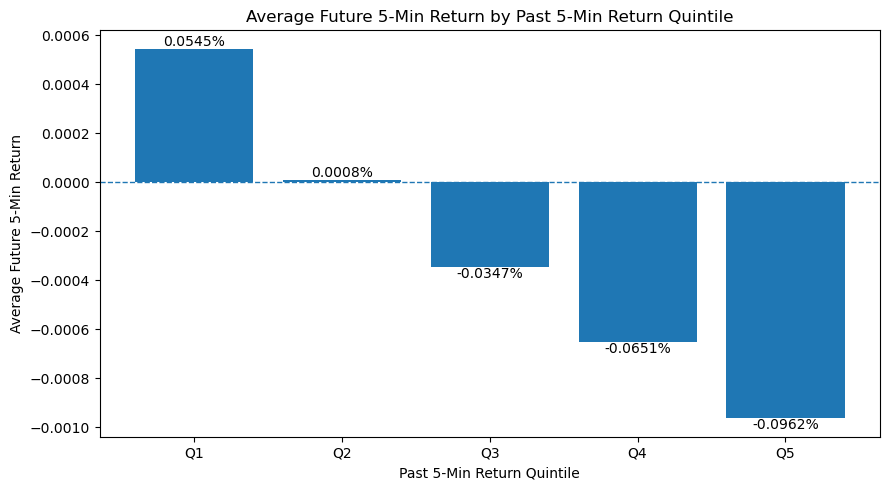

In [56]:
# ============================================================
# Momentum Quintile Grouped Return Plot
# ============================================================

plot_df = (
    momentum_quintile_summary
    .reset_index()
)

plt.figure(figsize=(9, 5))

plt.bar(
    plot_df["momentum_quintile"],
    plot_df["avg_future_return"]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

for i, value in enumerate(
    plot_df["avg_future_return"]
):
    plt.text(
        i,
        value,
        f"{value:.4%}",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

plt.title(
    "Average Future 5-Min Return by Past 5-Min Return Quintile"
)

plt.xlabel("Past 5-Min Return Quintile")
plt.ylabel("Average Future 5-Min Return")

plt.tight_layout()
plt.show()

In [57]:
# ============================================================
# Momentum Reversal Q1-Q5 Spread
# ============================================================

q1_return = momentum_quintile_summary.loc[
    "Q1",
    "avg_future_return"
]

q5_return = momentum_quintile_summary.loc[
    "Q5",
    "avg_future_return"
]

reversal_spread = q1_return - q5_return

print(
    f"Q1 Average Future Return: {q1_return:.4%}"
)

print(
    f"Q5 Average Future Return: {q5_return:.4%}"
)

print(
    f"Q1 - Q5 Reversal Spread: {reversal_spread:.4%}"
)

Q1 Average Future Return: 0.0545%
Q5 Average Future Return: -0.0962%
Q1 - Q5 Reversal Spread: 0.1507%


In [58]:
# ============================================================
# Momentum Quintile Analysis by Price Group
# ============================================================

price_group_quintile_summary = (
    momentum_quintile_df
    .groupby(
        [
            "price_group",
            "momentum_quintile"
        ],
        observed=True
    )
    .agg(
        n_obs=("future_return_5m", "size"),
        avg_past_return=("return_5m", "mean"),
        avg_future_return=("future_return_5m", "mean")
    )
    .reset_index()
)

display(price_group_quintile_summary)

,price_group,momentum_quintile,n_obs,avg_past_return,avg_future_return
0,Low Price,Q1,763,-0.006916,-0.000182
1,Low Price,Q2,706,-0.002545,-0.000101
2,Low Price,Q3,730,-0.000358,-0.000392
3,Low Price,Q4,709,0.001865,-0.000882
4,Low Price,Q5,712,0.006547,-0.001122
5,Mid Price,Q1,636,-0.007062,0.000919
6,Mid Price,Q2,744,-0.002527,-0.000148
7,Mid Price,Q3,785,-0.000492,-0.000298
8,Mid Price,Q4,767,0.001638,-0.000540
9,Mid Price,Q5,677,0.007540,-0.000666


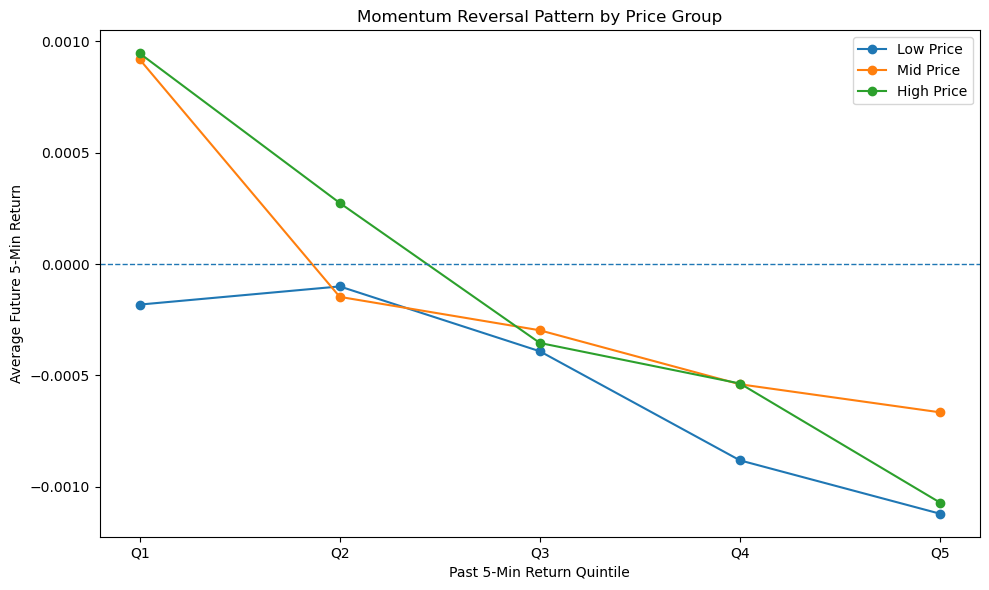

In [59]:
# ============================================================
# Momentum Reversal by Price Group
# ============================================================

plt.figure(figsize=(10, 6))

for price_group in [
    "Low Price",
    "Mid Price",
    "High Price"
]:
    sub = price_group_quintile_summary[
        price_group_quintile_summary[
            "price_group"
        ] == price_group
    ]

    plt.plot(
        sub["momentum_quintile"],
        sub["avg_future_return"],
        marker="o",
        label=price_group
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Momentum Reversal Pattern by Price Group"
)

plt.xlabel("Past 5-Min Return Quintile")
plt.ylabel("Average Future 5-Min Return")

plt.legend()
plt.tight_layout()
plt.show()

#### Momentum Reversal Findings

The quintile analysis provides direct evidence of a systematic short-horizon reversal pattern.

Observations are sorted into five groups based on their past 5-minute returns. Average future 5-minute returns decline almost monotonically from the lowest past-return quintile to the highest past-return quintile.

The lowest past-return quintile generates an average future return of approximately 0.055%, while the highest past-return quintile generates an average future return of approximately -0.096%. The resulting Q1-Q5 reversal spread is approximately 0.151%, or 15 basis points.

This monotonic pattern supports the earlier negative IC results and suggests that the relationship is not driven solely by a small number of extreme observations.

The price-group decomposition reveals additional heterogeneity. Mid- and High-Price stocks exhibit a relatively symmetric reversal pattern: recent losers subsequently generate positive average returns, while recent winners generate negative future returns.

Low-Price stocks exhibit a different structure. Although future returns decline across momentum quintiles, the lowest past-return quintile does not generate positive average future returns. The reversal relationship therefore appears more concentrated among recent winners rather than representing a symmetric loser-rebound effect.

This asymmetry may be related to the stronger price discreteness and zero-return concentration previously observed among Low-Price stocks.

Overall, recent 5-minute return is currently one of the strongest and most economically interpretable predictors of future 5-minute returns in the sample.

## 12. Volatility Features

Volatility features measure the recent instability of prices and market liquidity.

Unlike price momentum, which captures the direction of recent price movements, volatility features focus on the magnitude and variability of short-term price changes.

The following features are constructed:

| Feature | Description |
|---|---|
| `volatility_1m` | Standard deviation of recent minute returns over a 1-minute window |
| `volatility_3m` | Standard deviation of recent minute returns over a 3-minute window |
| `volatility_5m` | Standard deviation of recent minute returns over a 5-minute window |
| `spread_change_1m` | One-minute change in relative bid-ask spread |

The objective is to test whether recent price or liquidity instability contains predictive information for future 5-minute returns.

In [69]:
# ============================================================
# Volatility Feature Construction
# ============================================================

master_feature_df = (
    master_feature_df
    .sort_values(["code", "date", "minute"])
    .copy()
)

group_keys = ["code", "date"]

# 1. Absolute 1-minute return
master_feature_df["abs_return_1m"] = (
    master_feature_df["return_1m"].abs()
)

# 2. Rolling return volatility
master_feature_df["volatility_3m"] = (
    master_feature_df
    .groupby(group_keys)["return_1m"]
    .transform(
        lambda x: x.rolling(
            window=3,
            min_periods=3
        ).std()
    )
)

master_feature_df["volatility_5m"] = (
    master_feature_df
    .groupby(group_keys)["return_1m"]
    .transform(
        lambda x: x.rolling(
            window=5,
            min_periods=5
        ).std()
    )
)

# 3. One-minute relative spread change
master_feature_df["spread_change_1m"] = (
    master_feature_df
    .groupby(group_keys)["relative_spread"]
    .pct_change()
)

volatility_features = [
    "abs_return_1m",
    "volatility_3m",
    "volatility_5m",
    "spread_change_1m"
]

display(
    master_feature_df[
        [
            "code",
            "date",
            "minute",
            "return_1m",
            "abs_return_1m",
            "volatility_3m",
            "volatility_5m",
            "relative_spread",
            "spread_change_1m",
            "future_return_5m",
            "price_group"
        ]
    ].head(15)
)

,code,date,minute,return_1m,abs_return_1m,volatility_3m,volatility_5m,relative_spread,spread_change_1m,future_return_5m,price_group
0,000570.SZ,2026-03-11,2026-03-11 09:30:00,NaN,NaN,NaN,NaN,0.001586,NaN,0.001586,Low Price
1,000570.SZ,2026-03-11,2026-03-11 09:31:00,0.000000,0.000000,NaN,NaN,0.001586,0.000000,-0.002379,Low Price
2,000570.SZ,2026-03-11,2026-03-11 09:32:00,-0.001586,0.001586,NaN,NaN,0.001589,0.001589,0.001589,Low Price
3,000570.SZ,2026-03-11,2026-03-11 09:33:00,-0.004766,0.004766,0.002427,NaN,0.001596,0.004789,0.004789,Low Price
4,000570.SZ,2026-03-11,2026-03-11 09:34:00,0.004789,0.004789,0.004865,NaN,0.001589,-0.004766,-0.001589,Low Price
5,000570.SZ,2026-03-11,2026-03-11 09:35:00,0.003177,0.003177,0.005115,0.003799,0.001584,-0.003167,-0.006334,Low Price
6,000570.SZ,2026-03-11,2026-03-11 09:36:00,-0.003959,0.003959,0.004655,0.004267,0.003180,1.007949,-0.003975,Low Price
7,000570.SZ,2026-03-11,2026-03-11 09:37:00,0.002385,0.002385,0.003911,0.004375,0.001586,-0.501190,-0.007930,Low Price
8,000570.SZ,2026-03-11,2026-03-11 09:38:00,-0.001586,0.001586,0.003205,0.003615,0.001589,0.001589,-0.004766,Low Price
9,000570.SZ,2026-03-11,2026-03-11 09:39:00,-0.001589,0.001589,0.002293,0.003000,0.001591,0.001591,-0.004773,Low Price


In [70]:
# ============================================================
# Volatility Feature Diagnostics
# ============================================================

display(
    master_feature_df[
        volatility_features
    ].describe().T
)

display(
    master_feature_df[
        volatility_features
    ]
    .isna()
    .mean()
    .rename("missing_rate")
    .to_frame()
)

,count,mean,std,min,25%,50%,75%,max
abs_return_1m,12991.0,0.001826,0.002188,0.000000,0.000376,0.001416,0.002415,0.064729
volatility_3m,11937.0,0.002080,0.001868,0.000000,0.001018,0.001649,0.002704,0.053321
volatility_5m,10883.0,0.002187,0.001689,0.000000,0.001191,0.001833,0.002734,0.043132
spread_change_1m,12991.0,0.126657,0.716843,-0.953367,-0.002127,0.000000,0.002106,10.566963


,missing_rate
abs_return_1m,0.038985
volatility_3m,0.116955
volatility_5m,0.194925
spread_change_1m,0.038985


In [71]:
# ============================================================
# Volatility Feature Evaluation
# ============================================================

volatility_eval = evaluate_feature_family(
    master_feature_df,
    volatility_features,
    "Volatility"
)

print("Pooled IC:")
display(volatility_eval["pooled_ic"])

print("Daily IC Summary:")
display(volatility_eval["daily_ic_summary"])

print("Price-Group Rank IC:")
display(volatility_eval["price_group_ic_pivot"])

print("Price-Group Daily IC Summary:")
display(volatility_eval["price_group_daily_summary"])

Pooled IC:


,family,feature,pearson_ic,rank_ic,abs_rank_ic,n_obs,signal_direction
0,Volatility,volatility_5m,-0.094362,-0.021106,0.021106,10883,Negative
1,Volatility,volatility_3m,-0.051664,-0.020277,0.020277,11937,Negative
2,Volatility,abs_return_1m,-0.043749,-0.017699,0.017699,12991,Negative
3,Volatility,spread_change_1m,-0.007325,0.009162,0.009162,12991,Positive


Daily IC Summary:


,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir,abs_mean_daily_ic
feature,,,,,,
spread_change_1m,0.028264,0.036783,0.772727,22,0.768395,0.028264
volatility_5m,-0.014765,0.146880,0.500000,22,-0.100523,0.014765
volatility_3m,-0.013244,0.118508,0.545455,22,-0.111756,0.013244
abs_return_1m,-0.003237,0.089015,0.545455,22,-0.036368,0.003237


Price-Group Rank IC:


price_group,High Price,Low Price,Mid Price
feature,,,
abs_return_1m,-0.020607,-0.020011,-0.007903
spread_change_1m,0.017137,0.030479,-0.013713
volatility_3m,-0.027603,-0.038990,0.003429
volatility_5m,-0.028232,-0.040580,-0.001012


Price-Group Daily IC Summary:


,price_group,feature,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir
0,High Price,abs_return_1m,-0.028550,0.102654,0.500000,22,-0.278115
1,High Price,spread_change_1m,0.022065,0.039215,0.681818,22,0.562671
2,High Price,volatility_3m,-0.048672,0.157610,0.363636,22,-0.308815
3,High Price,volatility_5m,-0.043851,0.177147,0.363636,22,-0.247543
4,Low Price,abs_return_1m,0.017760,0.096046,0.681818,22,0.184911
5,Low Price,spread_change_1m,0.085068,0.090957,0.818182,22,0.935252
6,Low Price,volatility_3m,-0.006709,0.119834,0.409091,22,-0.055983
7,Low Price,volatility_5m,-0.000335,0.168953,0.454545,22,-0.001980
8,Mid Price,abs_return_1m,0.012023,0.118853,0.545455,22,0.101158
9,Mid Price,spread_change_1m,0.005219,0.046592,0.590909,22,0.112014


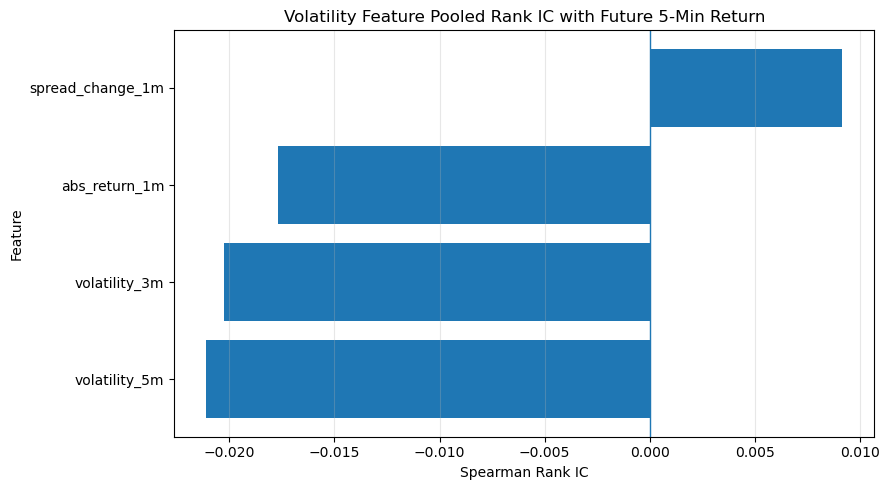

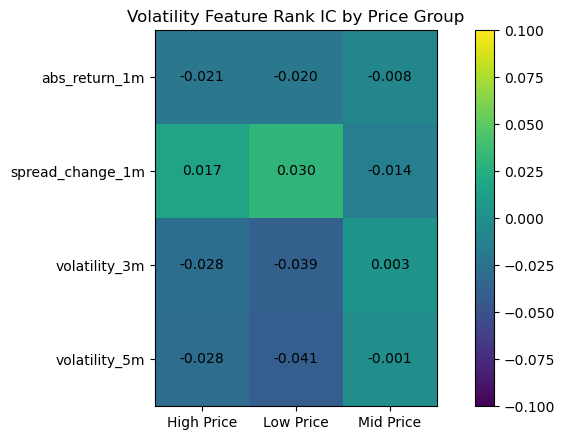

In [72]:
# ============================================================
# Volatility Feature IC Visualization
# ============================================================

plot_rank_ic_bar(
    volatility_eval["pooled_ic"],
    "Volatility Feature Pooled Rank IC with Future 5-Min Return"
)

plot_price_group_ic(
    volatility_eval["price_group_ic_pivot"],
    "Volatility Feature Rank IC by Price Group"
)

单纯的价格波动率对未来 5 分钟收益方向预测较弱；反而 spread 的短期变化出现了更稳定的预测关系，尤其是在 Low Price stocks。Spread change may capture a short-term liquidity state that contains predictive information, particularly among Low Price stocks.
Low Price stocks 更适合看 order-book / liquidity state；High Price stocks 的 recent price path，尤其 short-term reversal，更有预测力。

Recent price volatility shows only weak and unstable relationships with future 5-minute return direction. Although `volatility_3m` and `volatility_5m` have slightly negative pooled Rank IC, their daily IC is close to zero and highly variable across trading days.

In contrast, `spread_change_1m` exhibits a more stable positive relationship with future returns. This pattern is particularly strong among Low-Price stocks, where the feature has a mean daily IC of approximately 0.085 and a positive IC ratio above 80%.

The results suggest that pure price volatility contains limited directional information, while short-term changes in liquidity conditions may be more informative. The stronger spread-change signal among Low-Price stocks is also consistent with earlier findings that order-book and liquidity-state features are relatively more informative in this price group.

## 10. Interim Feature Screening Framework

At this stage, feature screening should not be based only on pooled IC.

The decision framework is:

| Evidence | Meaning |
|---|---|
| Pooled IC strong, same sign across price groups | Candidate robust signal |
| Pooled IC weak, strong IC in one price group | Price-conditional signal |
| Sign flips across price groups | Regime-dependent signal, use cautiously |
| IC weak across all groups | Drop as directional signal |
| High feature redundancy | Keep the stronger or more interpretable representative |

This structure will be reused for directional book evolution, momentum, and volatility features.


## 11. Next Step: Directional Book Evolution Features

The current evidence should guide the next feature family.

Snapshot features ask:

```text
What does the order book look like now?
```

Trade activity features ask:

```text
How active has the market been recently?
```

The next feature family should ask:

```text
How is the order book changing directionally?
```

Potential features:

- `depth_imbalance_change_1m`
- `depth_imbalance_change_3m`
- `bid_depth_change_1m`
- `ask_depth_change_1m`
- `signed_depth_change_1m`
- `microprice_momentum_1m`
- `microprice_momentum_3m`

These features will also be evaluated using pooled IC and price-group conditional IC.
